### Importación de datos



In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [ ]:
import pandas as pd

unidades = [("TIENDA 1", tienda), ("TIENDA 2", tienda2), ("TIENDA 3", tienda3), ("TIENDA 4", tienda4)]

total_global = sum(df['Precio'].sum() for _, df in unidades)
prom_fact_red = total_global / len(unidades)
vmu_global = total_global / sum(len(df) for _, df in unidades)

# --- REPORTE PLANO ---
print("\n" + "=" * 115)
print(f"{'ANÁLISIS DE FACTURACIÓN':^115}")
print("=" * 115)
print(f"FACTURACIÓN TOTAL (4 TIENDAS):   $ {total_global:>14,.2f}")
print(f"FACTURACIÓN PROMEDIO POR TIENDA: $ {prom_fact_red:>14,.2f}")
print(f"PRECIO PROMEDIO POR ARTÍCULO:    $ {vmu_global:>14,.2f}")
print("-" * 115)

# Definimos anchos fijos para cada columna
# Unidad(15), Fact(18), Share(10), VsMonto(20), Precio(15), VsPrecio(20)
head_fmt = "{:<15} | {:>18} | {:>10} | {:>20} | {:>15} | {:>20}"
print(head_fmt.format("UNIDAD", "FACTURACIÓN", "SHARE %", "VS PROM. MONTO", "$ PROM. ART.", "VS PROM. PRECIO"))
print("-" * 115)

for nombre, df in unidades:
    monto = df['Precio'].sum()
    vmu_tienda = df['Precio'].mean()
    share = f"{(monto / total_global) * 100:>8.1f}%"

    diff_monto = monto - prom_fact_red
    diff_vmu = vmu_tienda - vmu_global

    # Formateo:
    txt_monto = f"${monto:,.2f}"
    txt_vmu   = f"${vmu_tienda:,.2f}"

    # Aquí forzamos que el signo esté pegado al $ y el $ al número
    txt_diff_monto = f"{'+$' if diff_monto >= 0 else '-$'}{abs(diff_monto):,.0f}"
    txt_diff_vmu   = f"{'+$' if diff_vmu >= 0 else '-$'}{abs(diff_vmu):,.2f}"

    print(head_fmt.format(
        nombre,
        txt_monto,
        share,
        txt_diff_monto,
        txt_vmu,
        txt_diff_vmu
    ))

print("-" * 115)
print(head_fmt.format("TOTAL RED", f"${total_global:,.2f}", "100.0%", "---", f"${vmu_global:,.2f}", "---"))
print("=" * 115 + "\n")


                                              ANÁLISIS DE FACTURACIÓN                                              
FACTURACIÓN TOTAL (4 TIENDAS):   $ 4,403,619,200.00
FACTURACIÓN PROMEDIO POR TIENDA: $ 1,100,904,800.00
PRECIO PROMEDIO POR ARTÍCULO:    $     466,732.29
-------------------------------------------------------------------------------------------------------------------
UNIDAD          |        FACTURACIÓN |    SHARE % |       VS PROM. MONTO |    $ PROM. ART. |      VS PROM. PRECIO
-------------------------------------------------------------------------------------------------------------------
TIENDA 1        |  $1,150,880,400.00 |      26.1% |         +$49,975,600 |     $487,867.91 |          +$21,135.62
TIENDA 2        |  $1,116,343,500.00 |      25.4% |         +$15,438,700 |     $473,227.43 |           +$6,495.13
TIENDA 3        |  $1,098,019,600.00 |      24.9% |          -$2,885,200 |     $465,459.77 |           -$1,272.52
TIENDA 4        |  $1,038,375,700.00 |   

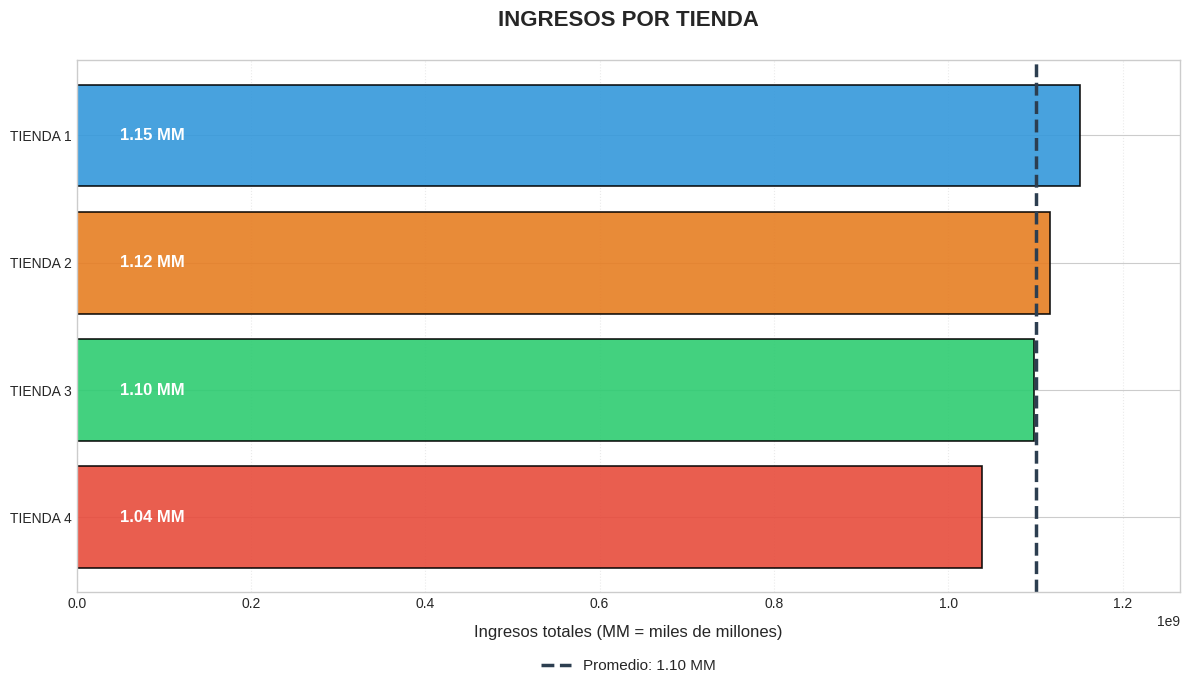

In [ ]:
import matplotlib.pyplot as plt

# --- DISTRIBUCIÓN DE INGRESOS POR TIENDA ---

# Preparación de datos y promedio
nombres = ["TIENDA 1", "TIENDA 2", "TIENDA 3", "TIENDA 4"]
ingresos = [
    tienda['Precio'].sum(),
    tienda2['Precio'].sum(),
    tienda3['Precio'].sum(),
    tienda4['Precio'].sum()
]
promedio = sum(ingresos) / len(ingresos)

# Paleta de colores
colores = ["#3498db", "#e67e22", "#2ecc71", "#e74c3c"]

# Configuración del gráfico horizontal
plt.figure(figsize=(12, 7))
barras = plt.barh(nombres, ingresos, color=colores, alpha=0.9, edgecolor='black', linewidth=1.2)

# Línea vertical de referencia (Promedio)
plt.axvline(x=promedio, color='#2c3e50', linestyle='--', linewidth=2.5)

# Etiquetas de datos internas alineadas a la izquierda
for barra in barras:
    ancho = barra.get_width()
    plt.text(5e7, barra.get_y() + barra.get_height()/2,
             f'{ancho/1e9:.2f} MM', va='center', ha='left',
             fontsize=12, fontweight='bold', color='white')

# Diseño y rotulación
plt.title('INGRESOS POR TIENDA', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Ingresos totales (MM = miles de millones)', fontsize=12, labelpad=10)
plt.grid(axis='x', linestyle=':', alpha=0.4)
plt.xlim(0, max(ingresos) * 1.1)
plt.gca().invert_yaxis()

# Notas aclaratorias
plt.legend([f'Promedio: {promedio/1e9:.2f} MM'],
           loc='upper center', bbox_to_anchor=(0.5, -0.1),
           ncol=1, frameon=False, fontsize=11)

plt.tight_layout()
plt.show()

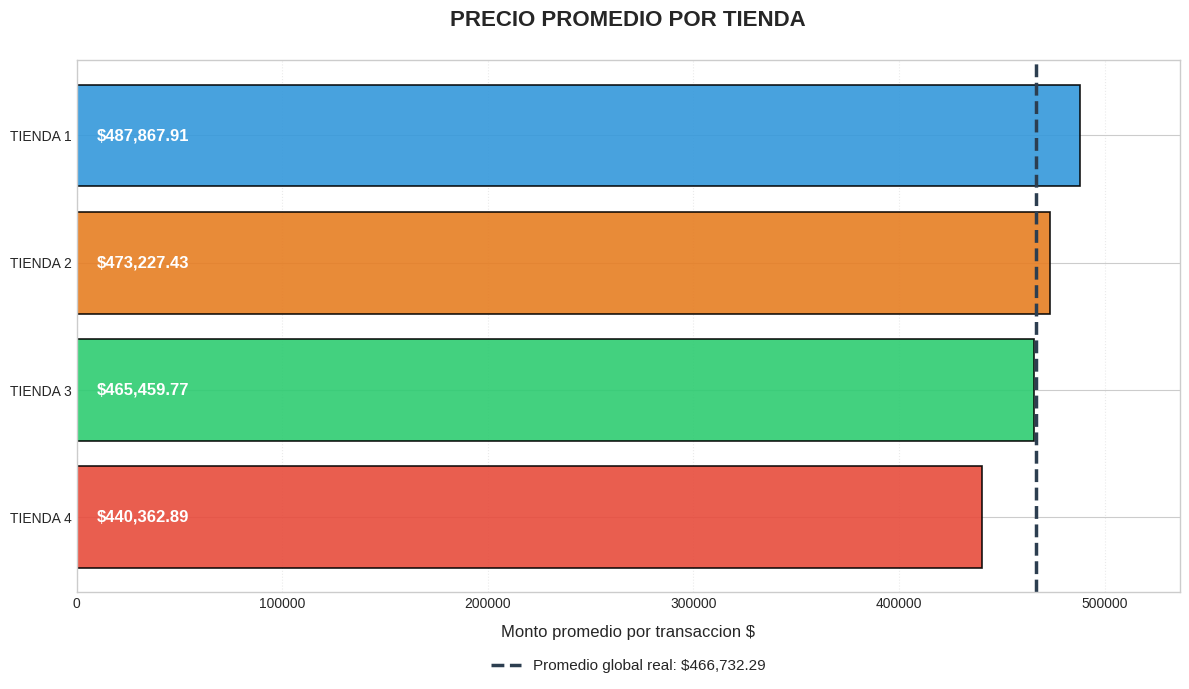

In [ ]:
import matplotlib.pyplot as plt

# --- TICKET PROMEDIO POR TIENDA ---

nombres = ["TIENDA 1", "TIENDA 2", "TIENDA 3", "TIENDA 4"]
tickets = [
    tienda['Precio'].mean(),
    tienda2['Precio'].mean(),
    tienda3['Precio'].mean(),
    tienda4['Precio'].mean()
]

# CALCULO REAL: Facturacion Total entre Total de Articulos
total_global = sum(df['Precio'].sum() for df in [tienda, tienda2, tienda3, tienda4])
total_articulos = sum(len(df) for df in [tienda, tienda2, tienda3, tienda4])
promedio_t = total_global / total_articulos

colores = ["#3498db", "#e67e22", "#2ecc71", "#e74c3c"]

# CORRECCIÓN DE SINTAXIS: figsize debe recibir una tupla (12, 7)
plt.figure(figsize=(12, 7))
barras = plt.barh(nombres, tickets, color=colores, alpha=0.9, edgecolor='black', linewidth=1.2)

# Linea vertical de referencia para el promedio global real
plt.axvline(x=promedio_t, color='#2c3e50', linestyle='--', linewidth=2.5)

# Etiquetas de datos internas cargadas a la IZQUIERDA
for barra in barras:
    ancho = barra.get_width()
    offset = max(tickets) * 0.02
    plt.text(offset, barra.get_y() + barra.get_height()/2,
             f'${ancho:,.2f}', va='center', ha='left',
             fontsize=12, fontweight='bold', color='white')

plt.title('PRECIO PROMEDIO POR TIENDA', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Monto promedio por transaccion $', fontsize=12, labelpad=10)
plt.grid(axis='x', linestyle=':', alpha=0.4)
plt.xlim(0, max(tickets) * 1.1)
plt.gca().invert_yaxis()

# CORRECCIÓN DE SINTAXIS EN LEYENDA: bbox_to_anchor recibe tupla
plt.legend([f'Promedio global real: ${promedio_t:,.2f}'],
           loc='upper center', bbox_to_anchor=(0.5, -0.1),
           ncol=1, frameon=False, fontsize=11)

plt.tight_layout()
plt.show()

# 2. Ventas por categoría

In [ ]:
import pandas as pd

# --- VENTAS POR CATEGORÍA ---

def generar_reporte_categorias(nombre_tienda, df):
    # Agrupamos por categoría para obtener volumen, ticket promedio y costo de envío promedio
    analisis_cat = df.groupby('Categoría del Producto').agg({
        'Precio': ['count', 'mean'],
        'Costo de envío': 'mean'
    }).sort_values(by=('Precio', 'count'), ascending=False)

    total_unidades = analisis_cat[('Precio', 'count')].sum()

    # Encabezado del reporte
    print(f"\n>>> AUDITORÍA DE CATEGORÍAS Y LOGÍSTICA: {nombre_tienda}")
    print("-" * 85)
    print(f"{'CATEGORÍA':<25} | {'UNIDADES':>10} | {'%':>8} | {'TICKET PROM.':>15} | {'PROM. ENVÍO':>15}")
    print("-" * 85)

    # Listado de categorías
    for categoria, fila in analisis_cat.iterrows():
        cantidad = fila[('Precio', 'count')]
        ticket_prom = fila[('Precio', 'mean')]
        envio_prom = fila[('Costo de envío', 'mean')]
        porcentaje = (cantidad / total_unidades) * 100

        # Impresión de datos: Categoría, Unidades, Participación, Ticket Promedio y Promedio de Envío
        print(f"{categoria:<25} | {int(cantidad):>10} | {porcentaje:>7.1f}% | ${ticket_prom:>14,.2f} | ${envio_prom:>14,.2f}")

    # Pie de reporte
    print("-" * 85)
    print(f"{'TOTAL:':<25} | {int(total_unidades):>10} | {'100%':>8} | {'-':>15} | {'-':>15}")
    print("=" * 85 + "\n")

# Consolidado de las 4 tiendas
consolidado_red = pd.concat([tienda, tienda2, tienda3, tienda4])

# Ejecución para las 4 tiendas + El acumulado global
tiendas_datos = [
    (tienda, "TIENDA 1"),
    (tienda2, "TIENDA 2"),
    (tienda3, "TIENDA 3"),
    (tienda4, "TIENDA 4"),
    (consolidado_red, "GLOBAL (4 TIENDAS)")
]

for df, nombre in tiendas_datos:
    generar_reporte_categorias(nombre, df)


>>> AUDITORÍA DE CATEGORÍAS Y LOGÍSTICA: TIENDA 1
-------------------------------------------------------------------------------------
CATEGORÍA                 |   UNIDADES |        % |    TICKET PROM. |     PROM. ENVÍO
-------------------------------------------------------------------------------------
Muebles                   |        465 |    19.7% | $    403,513.33 | $     21,494.41
Electrónicos              |        448 |    19.0% | $    958,690.85 | $     51,258.26
Juguetes                  |        324 |    13.7% | $     55,542.28 | $      3,023.15
Electrodomésticos         |        312 |    13.2% | $  1,165,657.69 | $     61,935.90
Deportes y diversión      |        284 |    12.0% | $    138,345.07 | $      7,468.66
Instrumentos musicales    |        182 |     7.7% | $    501,642.86 | $     26,834.62
Libros                    |        173 |     7.3% | $     50,779.77 | $      2,699.42
Artículos para el hogar   |        171 |     7.2% | $     74,259.65 | $      3,764.91
---

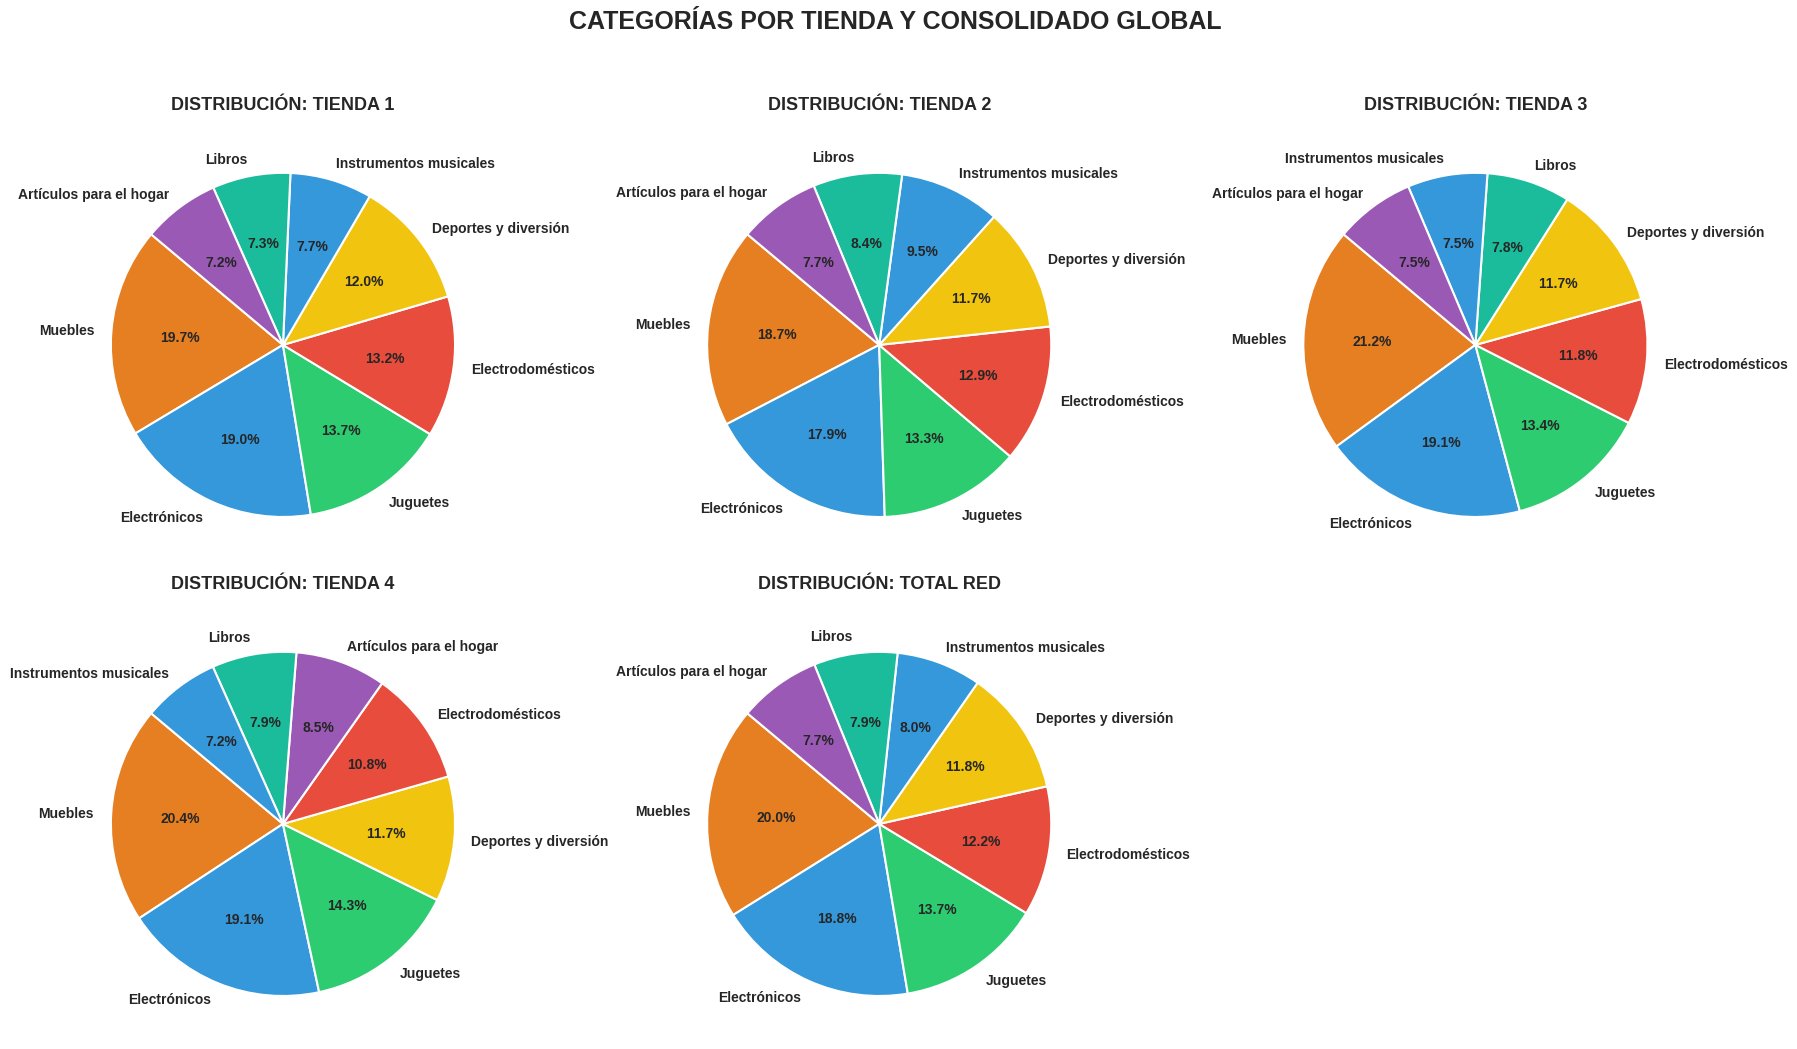

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# --- ANÁLISIS DE PARTICIPACIÓN POR CATEGORÍA ---

# Consolidación de datos para el cálculo global
df_total = pd.concat([tienda, tienda2, tienda3, tienda4])
lista_tiendas = [tienda, tienda2, tienda3, tienda4, df_total]
nombres_graficos = ["TIENDA 1", "TIENDA 2", "TIENDA 3", "TIENDA 4", "TOTAL RED"]

# Definición de paleta de colores
# Se asigna un color único a cada categoría existente en el set global
categorias_unicas = df_total['Categoría del Producto'].unique()
colores_base = ["#3498db", "#e67e22", "#2ecc71", "#e74c3c", "#9b59b6", "#f1c40f", "#1abc9c"]
color_map = {cat: colores_base[i % len(colores_base)] for i, cat in enumerate(categorias_unicas)}

# Configuración de la figura (Matriz de 2 filas x 3 columnas)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

# Generación iterativa de gráficos de pastel
for i, df in enumerate(lista_tiendas):
    # Conteo de frecuencia por categoría
    conteo = df['Categoría del Producto'].value_counts()

    # Mapeo de colores específicos para las categorías presentes en este DF
    colores_plot = [color_map[cat] for cat in conteo.index]

    # Trazado del gráfico de pastel
    axes[i].pie(conteo,
                labels=conteo.index,
                autopct='%1.1f%%',
                startangle=140,
                colors=colores_plot,
                wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
                textprops={'fontsize': 10, 'fontweight': 'bold'})

    axes[i].set_title(f"DISTRIBUCIÓN: {nombres_graficos[i]}", fontsize=13, fontweight='bold', pad=15)

# Ajuste final del lienzo
axes[5].axis('off')

plt.suptitle("CATEGORÍAS POR TIENDA Y CONSOLIDADO GLOBAL", fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

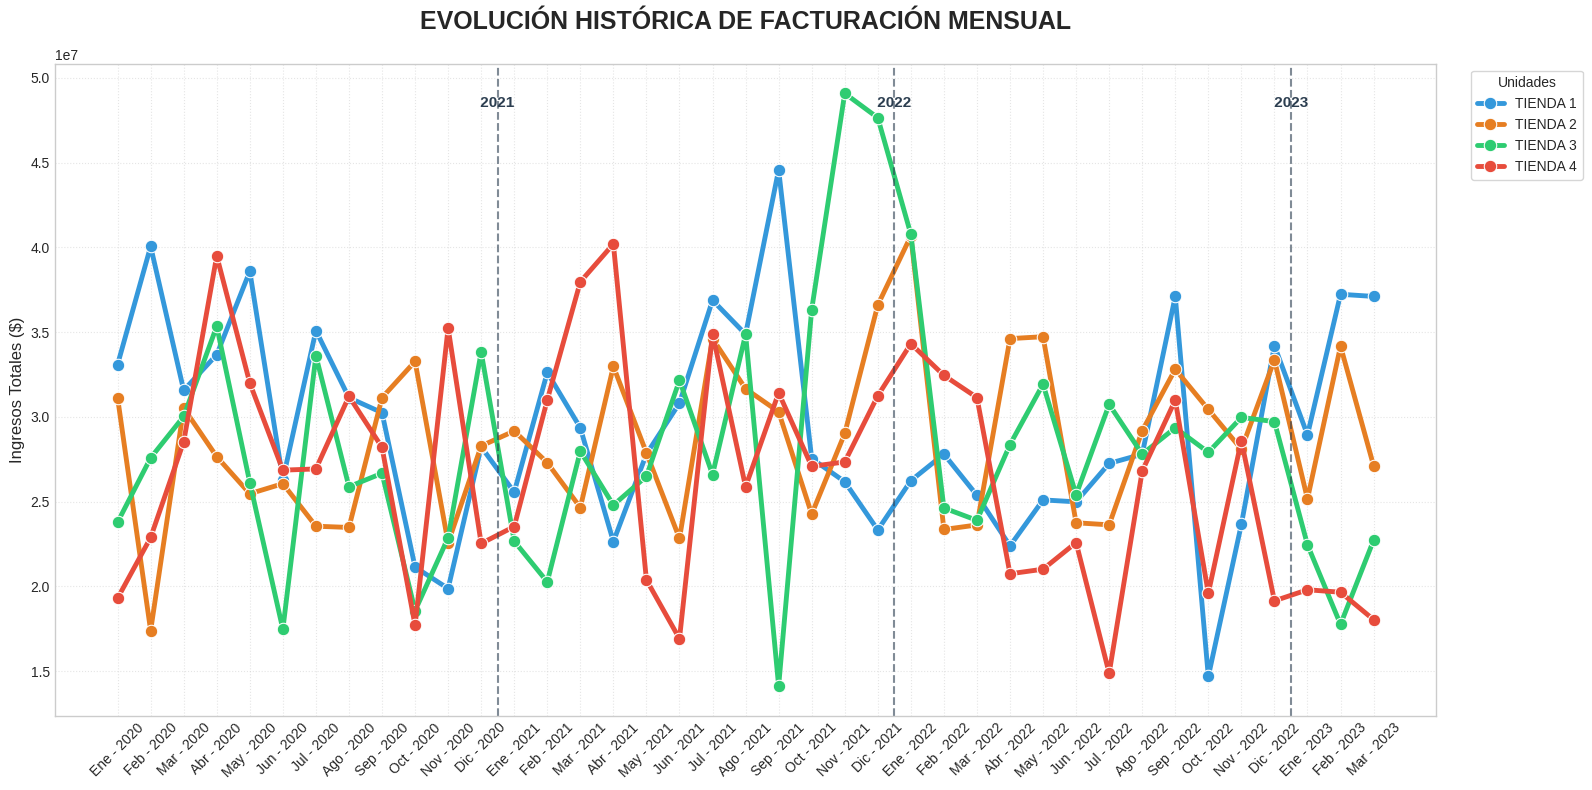

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analizar_tendencia_anual(tiendas, nombres):
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(16, 8))

    # Paleta exacta: Tienda 1 (Azul), 2 (Naranja), 3 (Verde), 4 (Rojo)
    paleta_tiendas = ["#3498db", "#e67e22", "#2ecc71", "#e74c3c"]

    meses_es = {
        1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr', 5: 'May', 6: 'Jun',
        7: 'Jul', 8: 'Ago', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'
    }

    df_global = pd.DataFrame()

    # --- PROCESAMIENTO ---
    for i, df in enumerate(tiendas):
        temp = df.copy()
        temp['Tienda_Nombre'] = nombres[i]

        # Buscador inteligente de columna de fecha
        col_fecha = [c for c in temp.columns if 'fecha' in c.lower()]
        if col_fecha:
            nombre_real = col_fecha[0]
            temp['Fecha_DT'] = pd.to_datetime(temp[nombre_real], dayfirst=True, errors='coerce')
            temp = temp.dropna(subset=['Fecha_DT'])
            df_global = pd.concat([df_global, temp])

    if df_global.empty:
        print("❌ No hay datos válidos para procesar.")
        return

    # --- ORGANIZACIÓN CRONOLÓGICA ---
    df_global['Año'] = df_global['Fecha_DT'].dt.year
    df_global['Mes_Num'] = df_global['Fecha_DT'].dt.month

    tendencia = df_global.groupby(['Año', 'Mes_Num', 'Tienda_Nombre'])['Precio'].sum().reset_index()
    tendencia = tendencia.sort_values(['Año', 'Mes_Num'])

    tendencia['Etiqueta_Mes'] = tendencia.apply(lambda x: f"{meses_es[x['Mes_Num']]} - {x['Año']}", axis=1)
    meses_unicos = tendencia['Etiqueta_Mes'].unique()

    # --- GRAFICADO ---
    sns.lineplot(
        data=tendencia,
        x='Etiqueta_Mes',
        y='Precio',
        hue='Tienda_Nombre',
        palette=paleta_tiendas,
        marker='o',
        markersize=9,
        linewidth=3.5,
        ax=ax,
        sort=False
    )

    # --- DIVISORES DE AÑO ---
    años_en_orden = [int(label.split(' - ')[1]) for label in meses_unicos]
    for i in range(len(años_en_orden) - 1):
        if años_en_orden[i] != años_en_orden[i+1]:
            ax.axvline(x=i + 0.5, color='#2c3e50', linestyle='--', linewidth=1.5, alpha=0.6)
            y_pos = ax.get_ylim()[1]
            ax.text(i + 0.5, y_pos * 0.95, f' {años_en_orden[i+1]} ',
                    color='#2c3e50', ha='center', fontweight='bold', fontsize=11)

    # --- ESTÉTICA FINAL ---
    ax.set_title('EVOLUCIÓN HISTÓRICA DE FACTURACIÓN MENSUAL', fontsize=18, fontweight='bold', pad=25)
    ax.set_ylabel('Ingresos Totales ($)', fontsize=12)

    # ELIMINADA ETIQUETA "Mes de Operación"
    ax.set_xlabel('')

    ax.legend(title='Unidades', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

    plt.xticks(rotation=45)
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Ejecución
analizar_tendencia_anual([tienda, tienda2, tienda3, tienda4],
                         ["TIENDA 1", "TIENDA 2", "TIENDA 3", "TIENDA 4"])

In [ ]:
import pandas as pd

def imprimir_resumen_ejecutivo(nombre, df):
    print(f"\n>>> {nombre}")
    print("=" * 50)

    # Agrupamos por método de pago para obtener ventas y calificación promedio
    resumen = df.groupby('Método de pago').agg({
        'Precio': 'count',
        'Calificación': 'mean'
    }).sort_values(by='Precio', ascending=False)

    for metodo, fila in resumen.iterrows():
        ventas = int(fila['Precio'])
        calif = fila['Calificación']

        # Generamos una barra visual de estrellas para Juan
        estrellas = "★" * int(round(calif)) + "☆" * (5 - int(round(calif)))

        print(f" * {metodo:<18} | {ventas:>4} arts. | {calif:.2f} {estrellas}")

# --- EJECUCIÓN ---
tiendas_lista = [tienda, tienda2, tienda3, tienda4]
nombres_lista = ["TIENDA 1", "TIENDA 2", "TIENDA 3", "TIENDA 4"]

for i in range(len(tiendas_lista)):
    imprimir_resumen_ejecutivo(nombres_lista[i], tiendas_lista[i])

# CONSOLIDADO FINAL (LAS 4 JUNTAS)
print("\n" + "█" * 50)
print(f"{'CONSOLIDADO GLOBAL DE LA RED':^50}")
print("█" * 50)
df_global = pd.concat(tiendas_lista)
imprimir_resumen_ejecutivo("GLOBAL (4 TIENDAS)", df_global)


>>> TIENDA 1
 * Tarjeta de crédito | 1704 arts. | 3.96 ★★★★☆
 * Nequi              |  483 arts. | 4.10 ★★★★☆
 * Cupón              |  137 arts. | 3.72 ★★★★☆
 * Tarjeta de débito  |   35 arts. | 4.17 ★★★★☆

>>> TIENDA 2
 * Tarjeta de crédito | 1721 arts. | 4.03 ★★★★☆
 * Nequi              |  467 arts. | 4.06 ★★★★☆
 * Cupón              |  141 arts. | 4.00 ★★★★☆
 * Tarjeta de débito  |   30 arts. | 4.17 ★★★★☆

>>> TIENDA 3
 * Tarjeta de crédito | 1753 arts. | 4.03 ★★★★☆
 * Nequi              |  468 arts. | 4.08 ★★★★☆
 * Cupón              |  101 arts. | 4.24 ★★★★☆
 * Tarjeta de débito  |   37 arts. | 3.95 ★★★★☆

>>> TIENDA 4
 * Tarjeta de crédito | 1720 arts. | 3.97 ★★★★☆
 * Nequi              |  482 arts. | 4.07 ★★★★☆
 * Cupón              |  125 arts. | 3.95 ★★★★☆
 * Tarjeta de débito  |   31 arts. | 4.35 ★★★★☆

██████████████████████████████████████████████████
           CONSOLIDADO GLOBAL DE LA RED           
██████████████████████████████████████████████████

>>> GLOBAL (4 TIENDAS

# 3. Calificación promedio de la tienda


In [ ]:
# Se obtienen los promedios de calificación por tienda redondeados a 2 decimales para evitar discrepancias visuales
r1 = round(tienda['Calificación'].mean(), 2)
r2 = round(tienda2['Calificación'].mean(), 2)
r3 = round(tienda3['Calificación'].mean(), 2)
r4 = round(tienda4['Calificación'].mean(), 2)

ratings = [r1, r2, r3, r4]
nombres = ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"]

# Se calcula el promedio global utilizando los valores previamente redondeados
promedio_global = round(sum(ratings) / len(ratings), 2)

print("CALIFICACIÓN PROMEDIO DE LAS TIENDAS")
print("="*60)
print(f"PROMEDIO GLOBAL DE LAS 4 TIENDAS: {promedio_global:.2f}")
print("-" * 60)

for i in range(len(ratings)):
    # La diferencia se calcula sobre valores de 2 decimales para que la resta sea exacta ante el usuario
    diferencia = round(ratings[i] - promedio_global, 2)

    # Clasificación del estado según la diferencia calculada
    if diferencia > 0:
        estado = "ENCIMA"
    elif diferencia < 0:
        estado = "DEBAJO"
    else:
        estado = "IGUAL"

    # Impresión de resultados con formato alineado
    print(f"{nombres[i]:<8}: {ratings[i]:.2f} estrellas | {estado:<6} de la media por {abs(diferencia):.2f}")

print("="*60)

CALIFICACIÓN PROMEDIO DE LAS TIENDAS
PROMEDIO GLOBAL DE LAS 4 TIENDAS: 4.02
------------------------------------------------------------
Tienda 1: 3.98 estrellas | DEBAJO de la media por 0.04
Tienda 2: 4.04 estrellas | ENCIMA de la media por 0.02
Tienda 3: 4.05 estrellas | ENCIMA de la media por 0.03
Tienda 4: 4.00 estrellas | DEBAJO de la media por 0.02


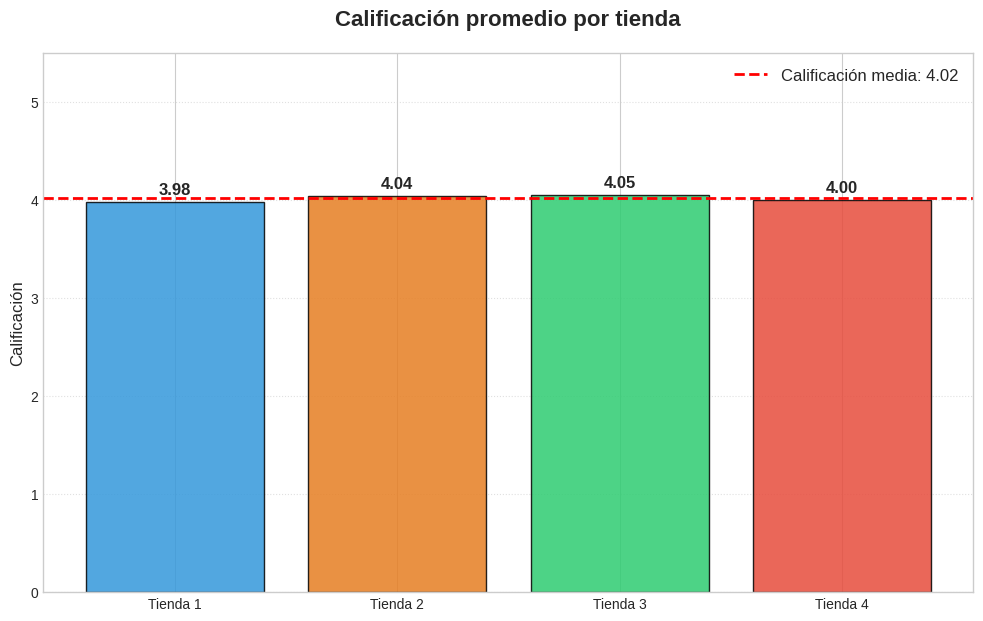

In [ ]:
import matplotlib.pyplot as plt

# --- PREPARACIÓN DE DATOS ---
ratings_individuales = [r1, r2, r3, r4]
nombres_tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
colores_fijos = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c']

# --- GENERACIÓN DEL GRÁFICO DE BARRAS ---
plt.figure(figsize=(12, 7))

# Dibujamos las barras con los colores corporativos
barras = plt.bar(nombres_tiendas, ratings_individuales, color=colores_fijos, edgecolor='black', alpha=0.85)

# Trazamos la línea de la Media Global (Benchmarking)
plt.axhline(y=promedio_global, color='red', linestyle='--', linewidth=2, label=f'Calificación media: {promedio_global:.2f}')

# Añadimos los valores exactos sobre cada barra para mayor precisión
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 0.05, f'{yval:.2f}',
             ha='center', va='bottom', fontweight='bold', fontsize=12)

# --- ESTÉTICA Y ETIQUETADO ---
plt.title('Calificación promedio por tienda', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Calificación', fontsize=12)
plt.ylim(0, 5.5)  # Ajustamos el límite para que se vean bien las etiquetas
plt.legend(loc='upper right', fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.show()

# 4. Productos más y menos vendidos

In [ ]:
import pandas as pd

def imprimir_reporte_ventas(nombre_tienda, df):
    resumen = df.groupby(['Producto', 'Categoría del Producto']).agg({
        'Precio': ['count', 'mean', 'sum']
    })

    resumen.columns = ['Ventas', 'Precio_Prom', 'Ingreso_Total']
    resumen = resumen.sort_values(by='Ventas', ascending=False)

    total_ventas = resumen['Ventas'].sum()
    total_ingreso = resumen['Ingreso_Total'].sum()

    # Forzamos ancho como entero para evitar el TypeError
    ancho = 138

    print(f"\n>>> ANÁLISIS DE VENTAS: {nombre_tienda}")
    print("-" * ancho)
    print(f"{'PRODUCTO':<35} | {'CATEGORÍA':<22} | {'VENTAS':>8} | {'% VOL':>8} | {'PRECIO PROM.':>15} | {'INGRESO TOTAL':>18} | {'% ING':>8}")
    print("-" * ancho)

    for (producto, categoria), fila in resumen.iterrows():
        ventas = fila['Ventas']
        precio = fila['Precio_Prom']
        ingreso = fila['Ingreso_Total']

        p_vol = (ventas / total_ventas) * 100
        p_ing = (ingreso / total_ingreso) * 100

        txt_prod = (producto[:33] + '..') if len(producto) > 35 else producto
        txt_cat = (categoria[:20] + '..') if len(categoria) > 22 else categoria

        print(f"{txt_prod:<35} | {txt_cat:<22} | {ventas:>8.0f} | {p_vol:>7.1f}% | ${precio:>14,.2f} | ${ingreso:>17,.2f} | {p_ing:>7.1f}%")

    print("-" * ancho)
    print(f"{'TOTALES CONSOLIDADOS:':<60} | {total_ventas:>8.0f} | {'100.0%':>8} | {'-':>15} | ${total_ingreso:>17,.2f} | {'100.0%':>8}")
    print("-" * ancho + "\n")

# --- EJECUCIÓN ---
tiendas = [tienda, tienda2, tienda3, tienda4]
nombres = ["TIENDA 1", "TIENDA 2", "TIENDA 3", "TIENDA 4"]
ancho_fijo = 138

for i in range(len(tiendas)):
    imprimir_reporte_ventas(nombres[i], tiendas[i])

print("=" * ancho_fijo)
print(f"{'CONSOLIDADO GLOBAL DE LA RED'.center(ancho_fijo)}")
print("=" * ancho_fijo)

df_global = pd.concat(tiendas)
imprimir_reporte_ventas("GLOBAL", df_global)


>>> ANÁLISIS DE VENTAS: TIENDA 1
------------------------------------------------------------------------------------------------------------------------------------------
PRODUCTO                            | CATEGORÍA              |   VENTAS |    % VOL |    PRECIO PROM. |      INGRESO TOTAL |    % ING
------------------------------------------------------------------------------------------------------------------------------------------
Armario                             | Muebles                |       60 |     2.5% | $    491,038.33 | $    29,462,300.00 |     2.6%
TV LED UHD 4K                       | Electrónicos           |       60 |     2.5% | $  2,369,170.00 | $   142,150,200.00 |    12.4%
Microondas                          | Electrodomésticos      |       60 |     2.5% | $    579,358.33 | $    34,761,500.00 |     3.0%
Secadora de ropa                    | Electrodomésticos      |       58 |     2.5% | $  1,018,317.24 | $    59,062,400.00 |     5.1%
Mesa de noche          

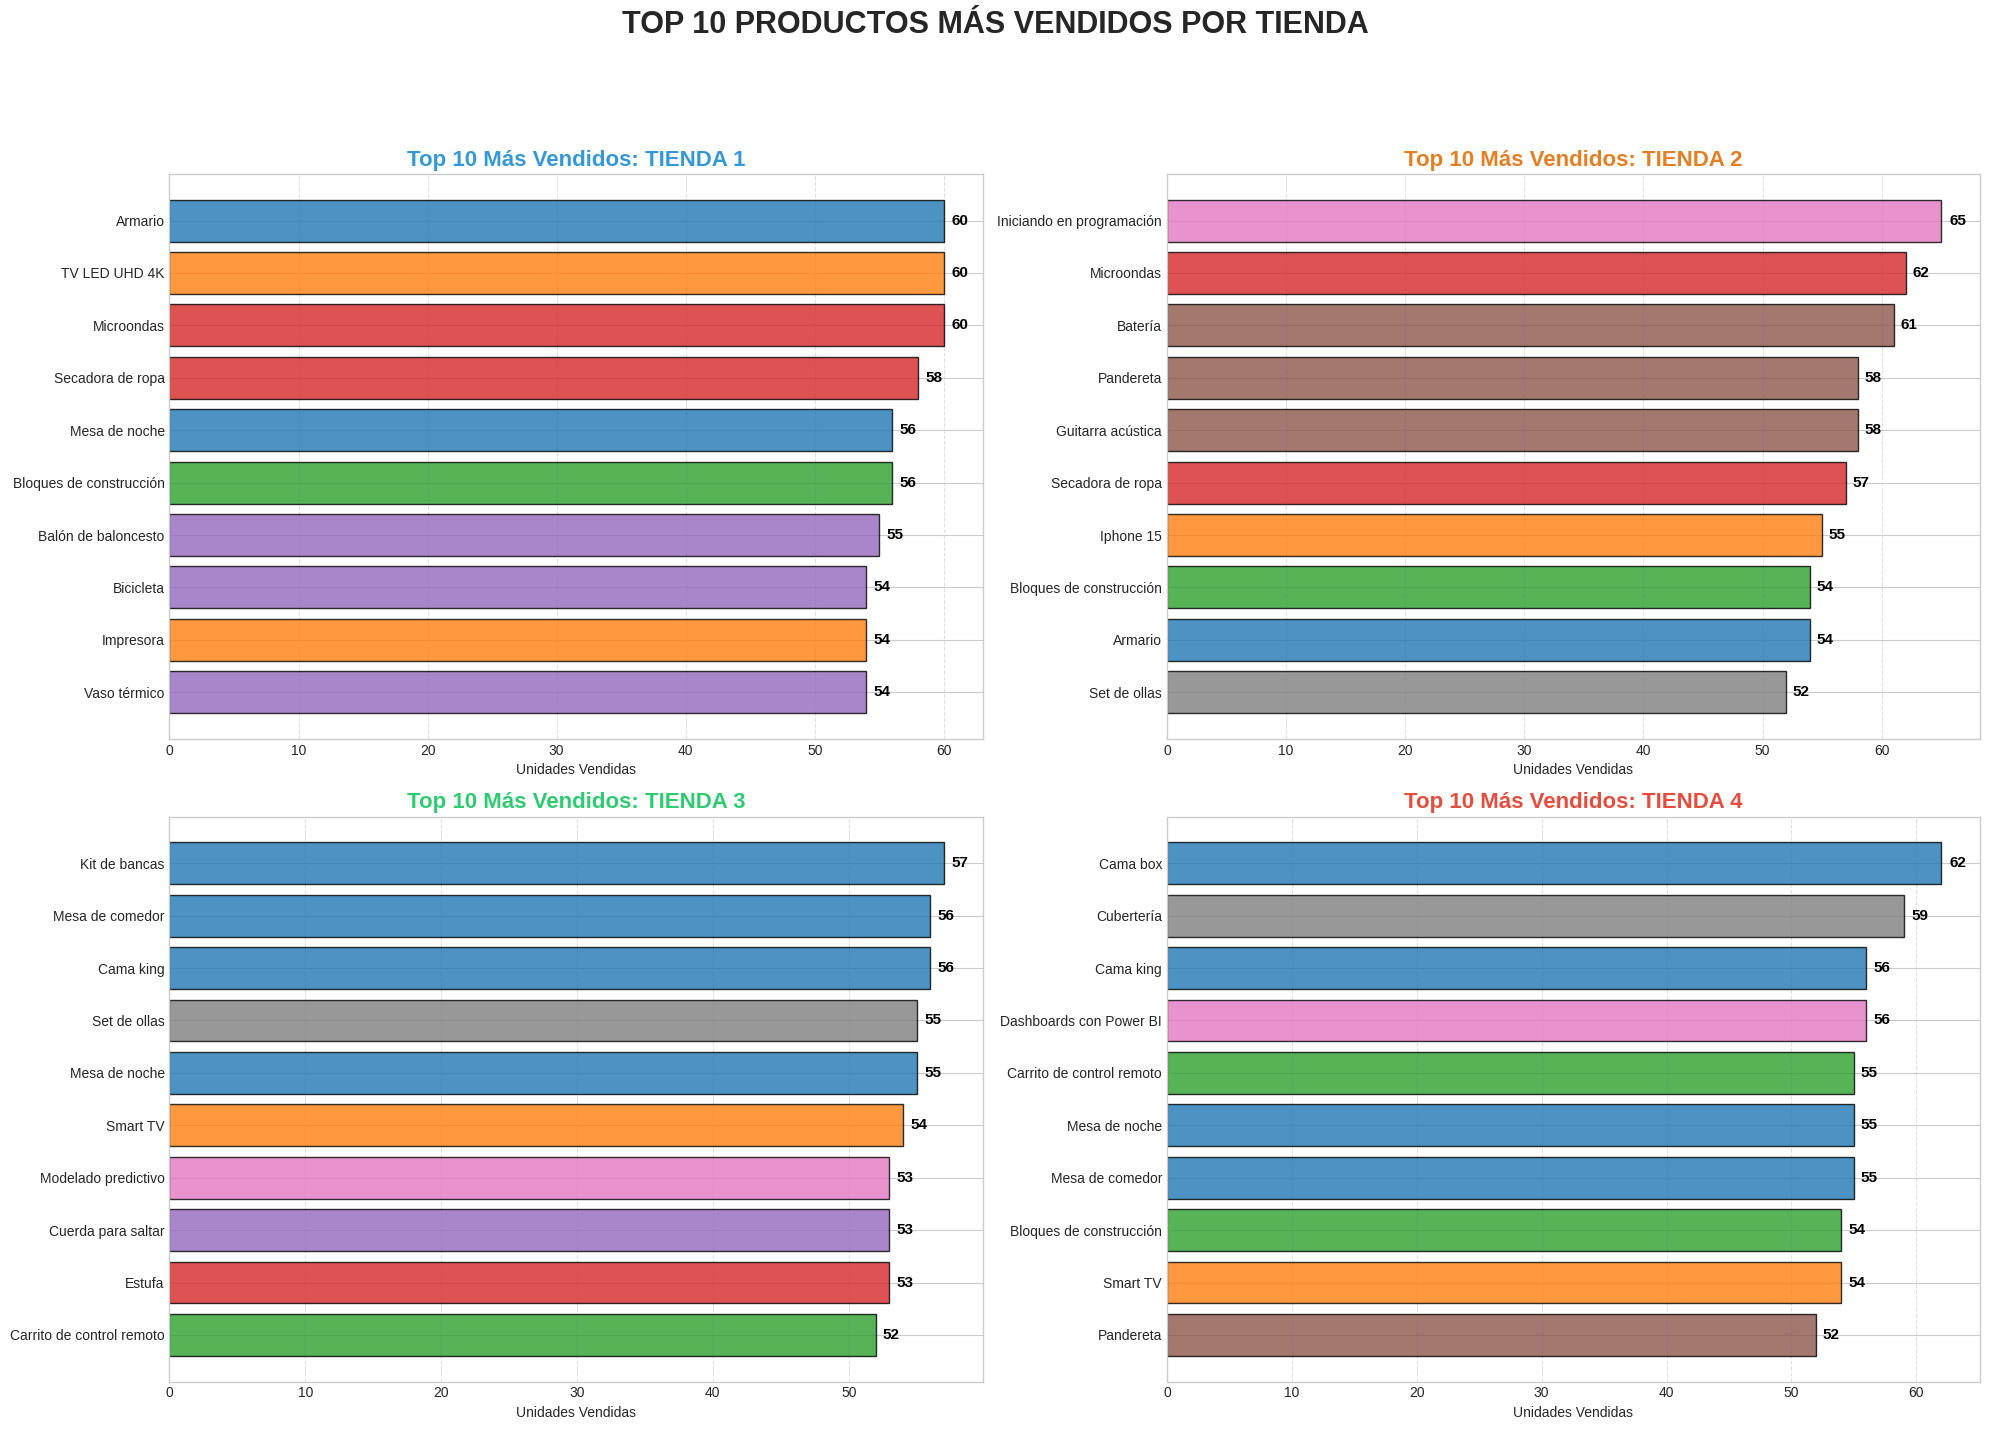

In [ ]:
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN DE IDENTIDAD VISUAL ---
colores_categorias = {
    "Muebles": "#1f77b4", "Electrónicos": "#ff7f0e", "Juguetes": "#2ca02c",
    "Electrodomésticos": "#d62728", "Deportes y diversión": "#9467bd",
    "Instrumentos musicales": "#8c564b", "Libros": "#e377c2", "Artículos para el hogar": "#7f7f7f"
}

colores_titulos = ["#3498db", "#e67e22", "#2ecc71", "#e74c3c"]
tiendas_lista = [tienda, tienda2, tienda3, tienda4]
nombres_tiendas = ["TIENDA 1", "TIENDA 2", "TIENDA 3", "TIENDA 4"]

# --- GENERACIÓN DEL GRÁFICO DE LOS MÁS VENDIDOS (TOP 10) ---
# Usamos plt.subplots para crear la rejilla de 2x2
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
axes = axes.flatten()

def graficar_top_productos(df, ax, nombre_tienda, color_titulo):
    # 1. Agrupamos y contamos, ordenamos DESCENDENTE para obtener los MÁS vendidos
    top_df = df.groupby(['Producto', 'Categoría del Producto']).size().sort_values(ascending=False).head(10).reset_index(name='Ventas')

    # 2. Asignamos colores por categoría
    colors = [colores_categorias.get(cat, '#bdc3c7') for cat in top_df['Categoría del Producto']]

    # 3. Dibujamos barras horizontales
    ax.barh(top_df['Producto'], top_df['Ventas'], color=colors, edgecolor='black', alpha=0.8)
    ax.invert_yaxis() # Esto pone el producto #1 en la parte superior

    # 4. Estética
    ax.set_title(f"Top 10 Más Vendidos: {nombre_tienda}", fontsize=16, fontweight='bold', color=color_titulo)
    ax.set_xlabel('Unidades Vendidas')
    ax.grid(axis='x', linestyle='--', alpha=0.6)

    # 5. Etiquetas de valor exacto al final de cada barra
    for i, v in enumerate(top_df['Ventas']):
        ax.text(v + (v * 0.01), i, str(int(v)), color='black', va='center', fontweight='bold', fontsize=11)

# Ejecutamos la función para cada cuadrante (las 4 tiendas)
for i in range(4):
    graficar_top_productos(tiendas_lista[i], axes[i], nombres_tiendas[i], colores_titulos[i])

plt.suptitle("TOP 10 PRODUCTOS MÁS VENDIDOS POR TIENDA\n", fontsize=22, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('top_10_productos_mas_vendidos.png')

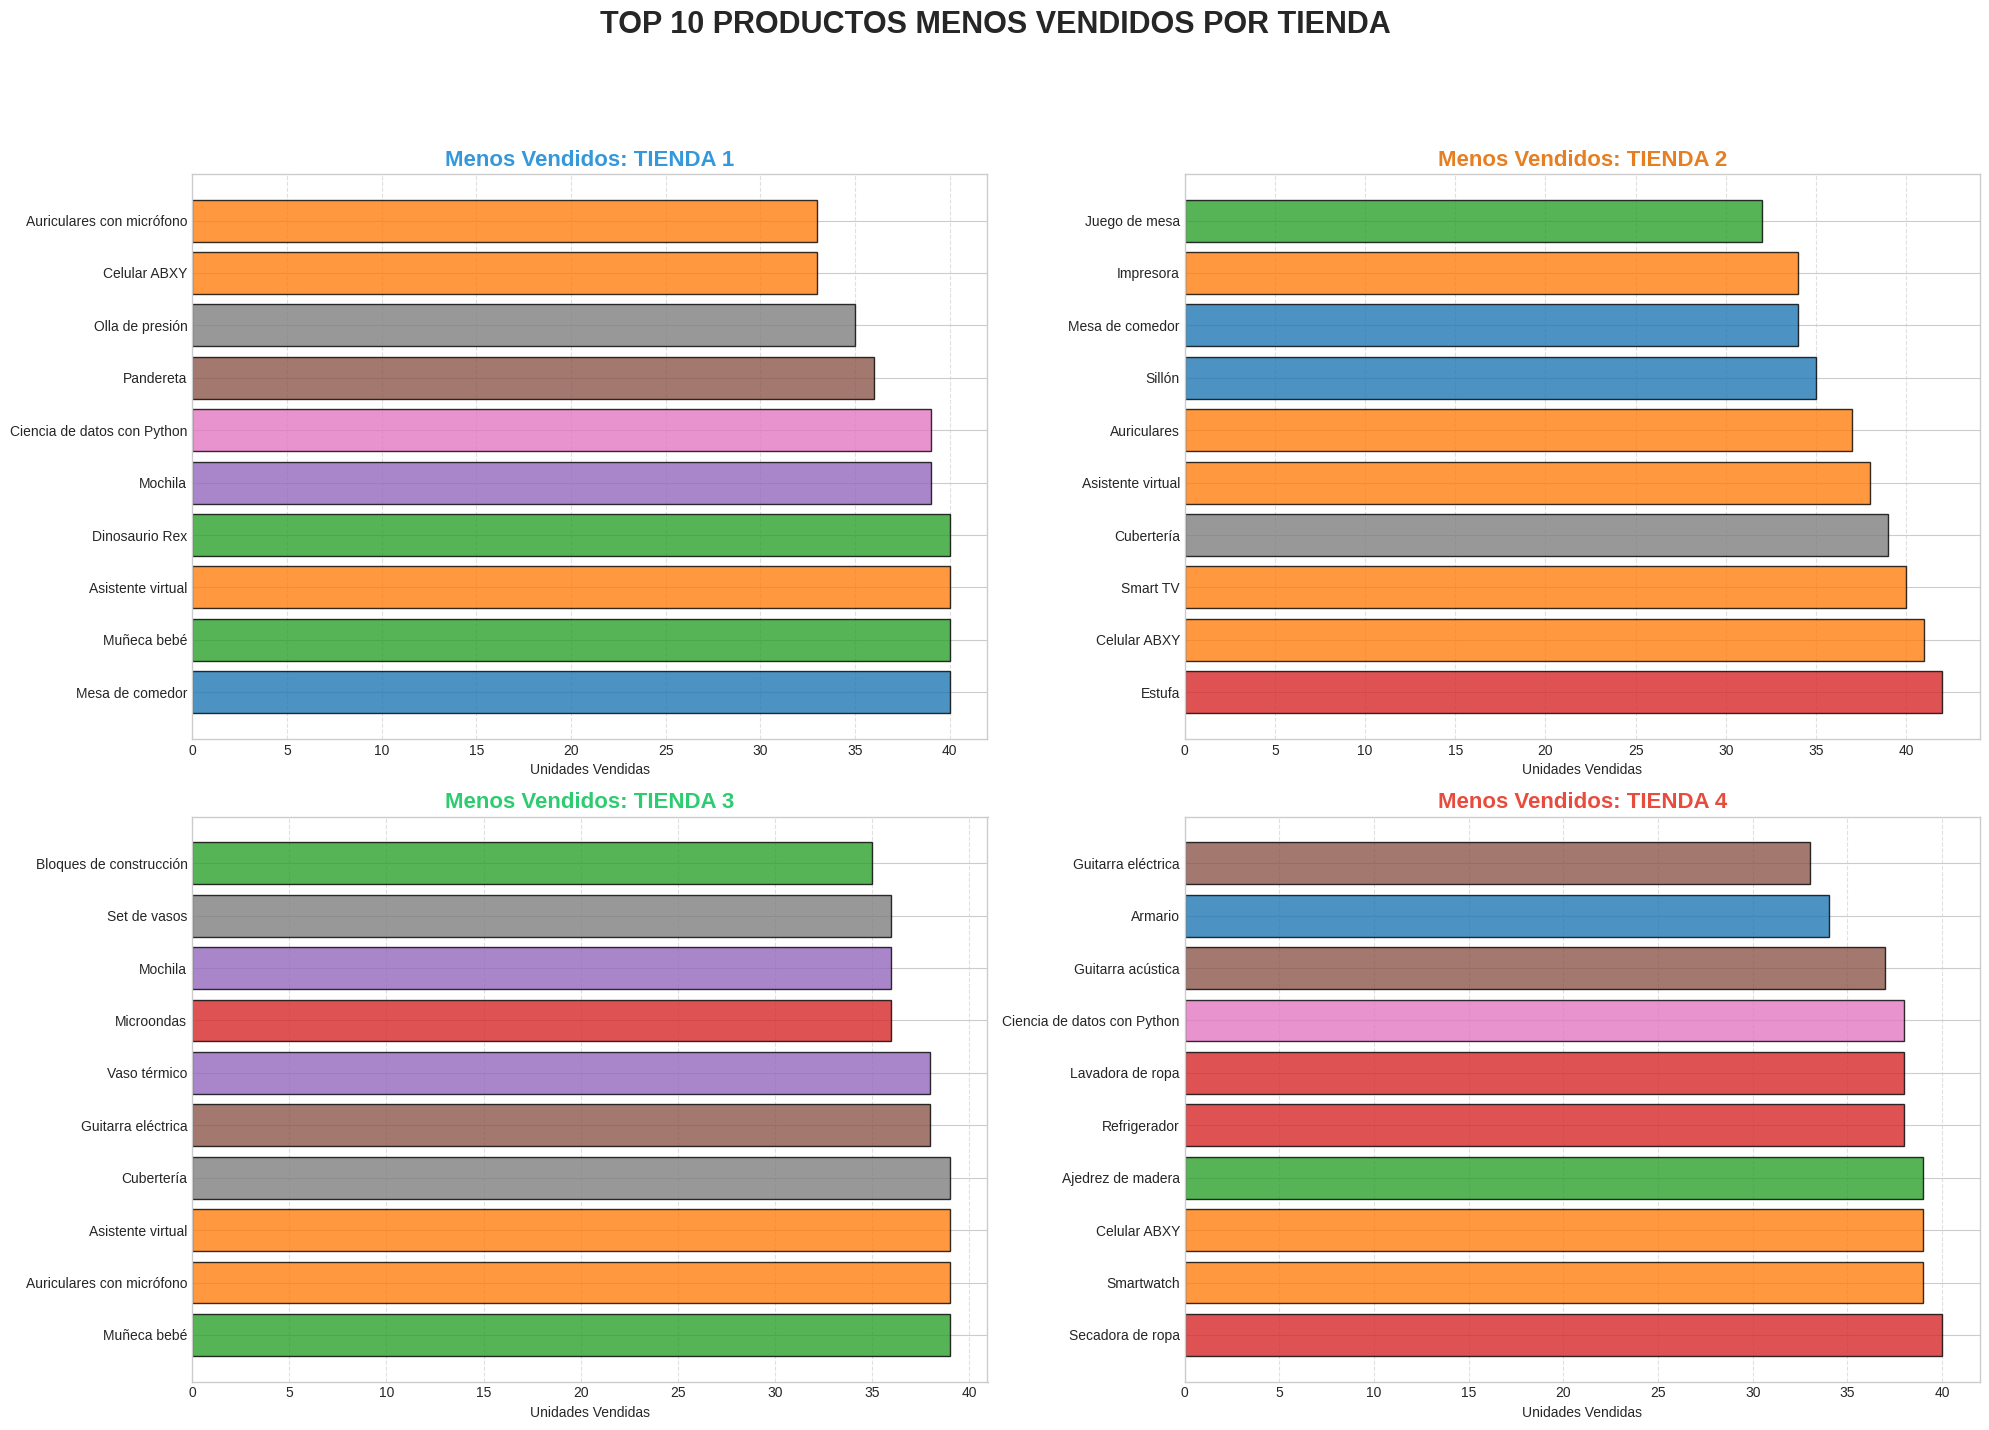

In [ ]:
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN DE IDENTIDAD VISUAL ---
colores_categorias = {
    "Muebles": "#1f77b4", "Electrónicos": "#ff7f0e", "Juguetes": "#2ca02c",
    "Electrodomésticos": "#d62728", "Deportes y diversión": "#9467bd",
    "Instrumentos musicales": "#8c564b", "Libros": "#e377c2", "Artículos para el hogar": "#7f7f7f"
}

colores_titulos = ["#3498db", "#e67e22", "#2ecc71", "#e74c3c"]
tiendas_lista = [tienda, tienda2, tienda3, tienda4]
nombres_tiendas = ["TIENDA 1", "TIENDA 2", "TIENDA 3", "TIENDA 4"]

# --- GENERACIÓN DEL GRÁFICO DE LOS MENOS VENDIDOS ---
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
axes = axes.flatten()

def graficar_bottom_productos(df, ax, nombre_tienda, color_titulo):
    # 1. Agrupamos y contamos, pero ordenamos ASCENDENTE para ver los menos vendidos
    # Usamos tail(10) después de un sort normal o head(10) después de un sort ascendente
    bottom_df = df.groupby(['Producto', 'Categoría del Producto']).size().sort_values(ascending=True).head(10).reset_index(name='Ventas')

    # 2. Asignamos colores por categoría
    colors = [colores_categorias.get(cat, '#bdc3c7') for cat in bottom_df['Categoría del Producto']]

    # 3. Dibujamos barras horizontales (invertimos para que el que menos vende esté arriba)
    ax.barh(bottom_df['Producto'], bottom_df['Ventas'], color=colors, edgecolor='black', alpha=0.8)
    ax.invert_yaxis()

    # 4. Estética
    ax.set_title(f"Menos Vendidos: {nombre_tienda}", fontsize=16, fontweight='bold', color=color_titulo)
    ax.set_xlabel('Unidades Vendidas')
    ax.grid(axis='x', linestyle='--', alpha=0.6)

# Ejecutamos la función para cada cuadrante
for i in range(4):
    graficar_bottom_productos(tiendas_lista[i], axes[i], nombres_tiendas[i], colores_titulos[i])

plt.suptitle("TOP 10 PRODUCTOS MENOS VENDIDOS POR TIENDA\n", fontsize=22, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 5. Envío promedio por tienda

In [ ]:
import pandas as pd

# Lista de unidades para procesamiento cíclico
unidades = [("TIENDA 1", tienda), ("TIENDA 2", tienda2), ("TIENDA 3", tienda3), ("TIENDA 4", tienda4)]

def generar_reporte_costos_envio(unidades):
    lista_promedios = []

    # 1. Procesamiento individual con limpieza profunda
    for nombre, original_df in unidades:
        # Creamos copia para no alterar el dataframe original y limpiamos categorías
        df = original_df.copy()
        df['Categoría del Producto'] = df['Categoría del Producto'].str.strip()

        # Identificamos columna de envío
        col_envio = 'Costo de envío' if 'Costo de envío' in df.columns else 'Costo de envio'

        # Agregación
        res = df.groupby('Categoría del Producto')[col_envio].mean().reset_index()
        res.rename(columns={col_envio: nombre}, inplace=True)
        lista_promedios.append(res)

    # 2. Consolidación (Merge)
    tabla_final = lista_promedios[0]
    for res in lista_promedios[1:]:
        tabla_final = pd.merge(tabla_final, res, on='Categoría del Producto', how='outer')

    # 3. Cálculo Global
    df_global = pd.concat([u[1] for u in unidades]).copy()
    df_global['Categoría del Producto'] = df_global['Categoría del Producto'].str.strip()
    col_glob = 'Costo de envío' if 'Costo de envío' in df_global.columns else 'Costo de envio'

    global_avg = df_global.groupby('Categoría del Producto')[col_glob].mean().reset_index()
    global_avg.rename(columns={col_glob: 'GLOBAL (RED)'}, inplace=True)

    # Unión final y orden alfabético
    tabla_final = pd.merge(tabla_final, global_avg, on='Categoría del Producto', how='outer').sort_values('Categoría del Producto')

    return tabla_final

# Ejecución
reporte_envios = generar_reporte_costos_envio(unidades)

# --- IMPRESIÓN DEL REPORTE FORMATEADO ---
ancho = 115
print(f"\n{'ANÁLISIS DE COSTO DE ENVÍO PROMEDIO POR CATEGORÍA Y TIENDA':^115}")
print("=" * ancho)
header = f"{'CATEGORÍA':<25} | {'TIENDA 1':>15} | {'TIENDA 2':>15} | {'TIENDA 3':>15} | {'TIENDA 4':>15} | {'GLOBAL':>15}"
print(header)
print("-" * ancho)

for _, fila in reporte_envios.iterrows():
    cat = fila['Categoría del Producto']
    t1, t2, t3, t4, gl = fila['TIENDA 1'], fila['TIENDA 2'], fila['TIENDA 3'], fila['TIENDA 4'], fila['GLOBAL (RED)']

    cat_fmt = (cat[:22] + "..") if len(cat) > 25 else cat
    val = lambda x: f"${x:>14,.2f}" if pd.notnull(x) else f"{'N/A':>15}"

    print(f"{cat_fmt:<25} | {val(t1)} | {val(t2)} | {val(t3)} | {val(t4)} | {val(gl)}")

print("-" * ancho)


                            ANÁLISIS DE COSTO DE ENVÍO PROMEDIO POR CATEGORÍA Y TIENDA                             
CATEGORÍA                 |        TIENDA 1 |        TIENDA 2 |        TIENDA 3 |        TIENDA 4 |          GLOBAL
-------------------------------------------------------------------------------------------------------------------
Artículos para el hogar   | $      3,764.91 | $      4,424.31 | $      4,589.83 | $      4,249.25 | $      4,261.78
Deportes y diversión      | $      7,468.66 | $      6,826.55 | $      6,942.60 | $      6,390.25 | $      6,910.69
Electrodomésticos         | $     61,935.90 | $     60,838.03 | $     62,928.78 | $     59,143.70 | $     61,267.45
Electrónicos              | $     51,258.26 | $     51,692.42 | $     48,460.98 | $     48,399.78 | $     49,922.18
Instrumentos musicales    | $     26,834.62 | $     24,811.16 | $     23,213.56 | $     23,258.24 | $     24,574.10
Juguetes                  | $      3,023.15 | $      2,835.78 | $      

# 6. Desempeño geográfico

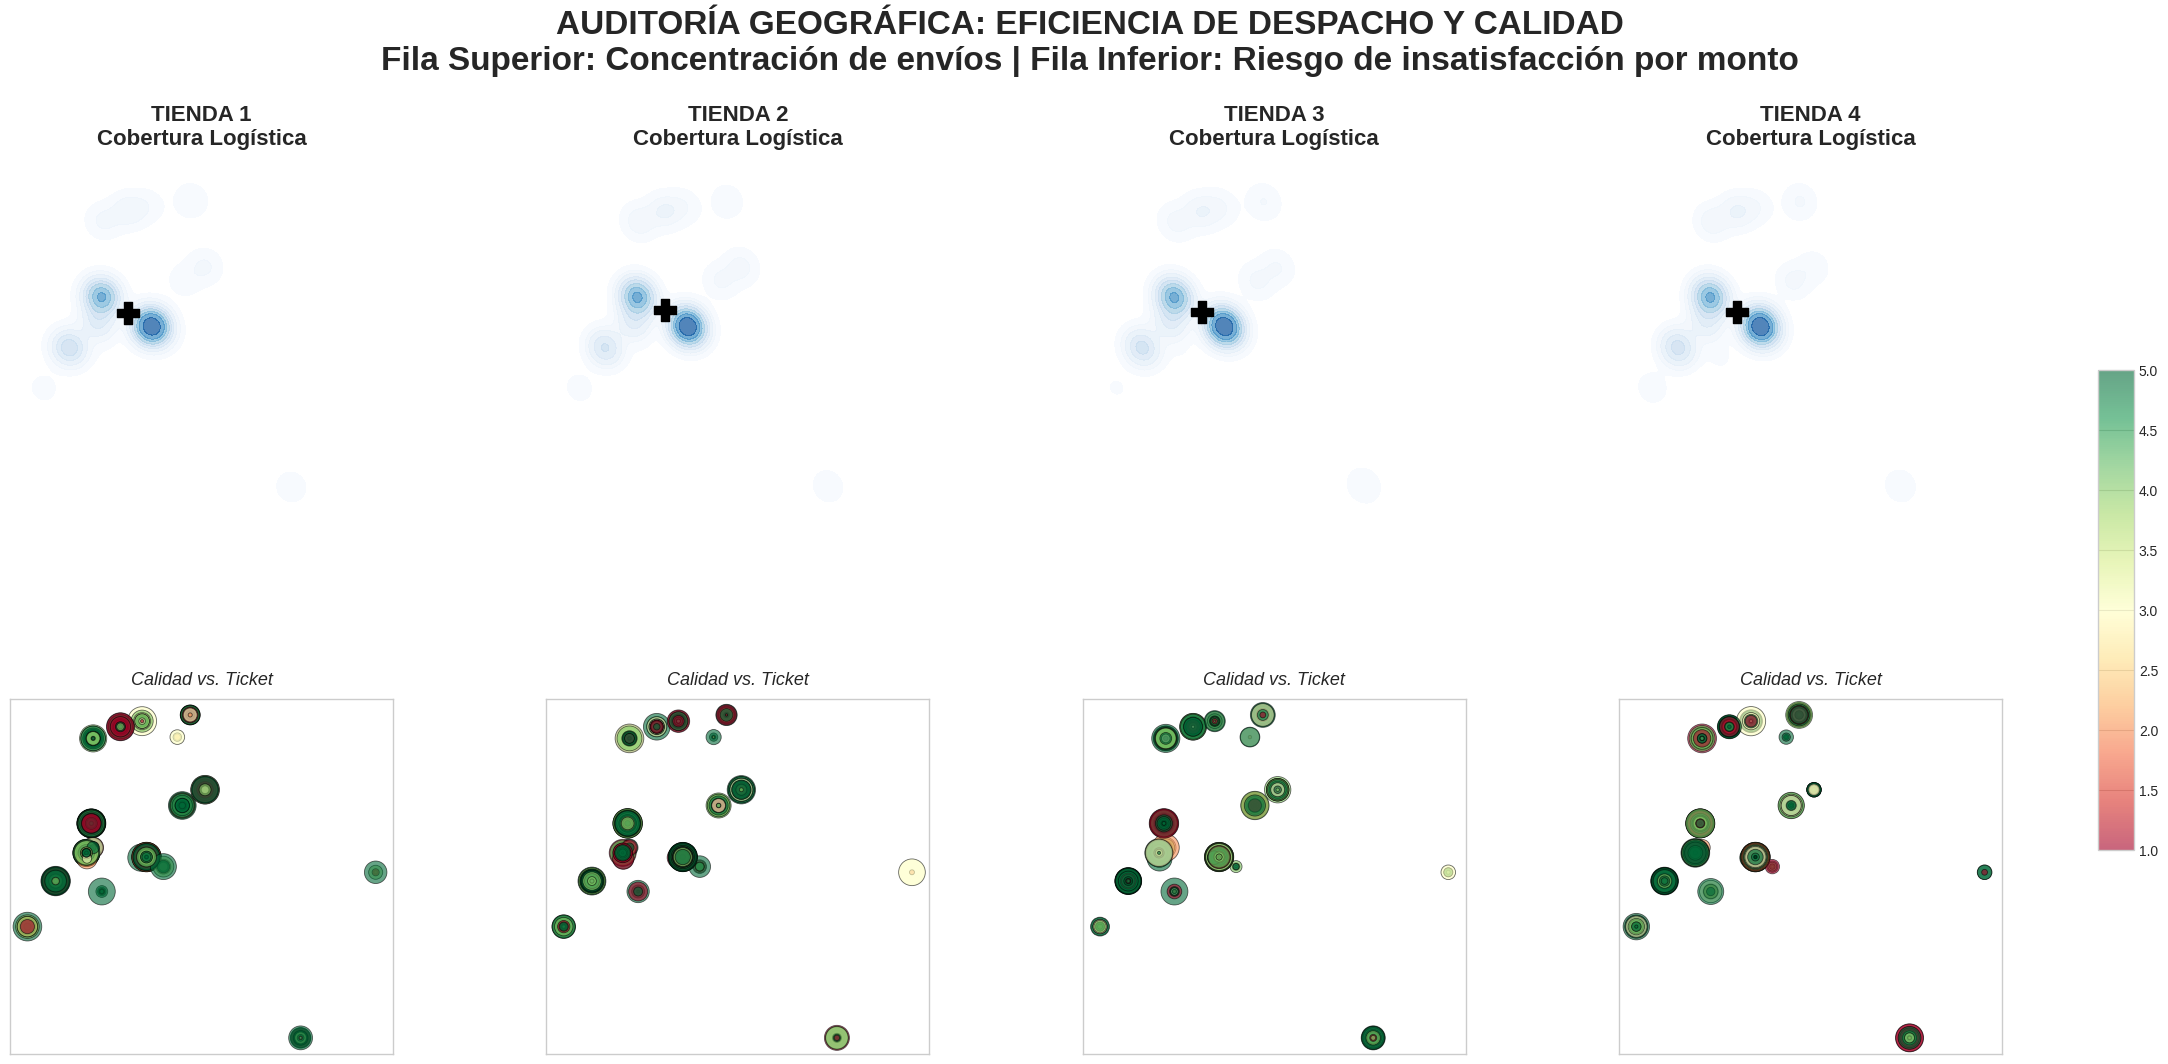

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualizar_desempeño_geografico(tiendas, nombres):
    plt.style.use('seaborn-v0_8-whitegrid')

    # Mantenemos el tamaño grande para que quepa todo
    fig, axes = plt.subplots(2, 4, figsize=(24, 12))

    cmap_densidad = "Blues"
    cmap_satisfaccion = "RdYlGn"

    for i in range(4):
        df = tiendas[i]

        # NIVEL 1: ALCANCE OPERATIVO
        ax1 = axes[0, i]
        sns.kdeplot(data=df, x="lon", y="lat", fill=True, cmap=cmap_densidad,
                    thresh=0.05, levels=10, alpha=0.7, ax=ax1)

        ax1.scatter(df['lon'].mean(), df['lat'].mean(), marker='P', s=250, color='black')
        ax1.set_title(f"{nombres[i]}\nCobertura Logística", fontweight='bold', fontsize=16, pad=15)
        ax1.axis('off')

        # NIVEL 2: INTEGRIDAD DE VENTA
        ax2 = axes[1, i]
        tamanos = (df['Precio'] / df['Precio'].max()) * 450

        scatter = ax2.scatter(df['lon'], df['lat'], c=df['Calificación'],
                              cmap=cmap_satisfaccion, s=tamanos, alpha=0.6,
                              edgecolors='black', linewidth=0.6, vmin=1, vmax=5)

        ax2.set_title(f"Calidad vs. Ticket", fontsize=13, style='italic', pad=10)

        # Limpieza absoluta de ejes
        ax2.set_xlabel("")
        ax2.set_ylabel("")
        ax2.set_xticks([])
        ax2.set_yticks([])

    # AJUSTE DE ESPACIOS (Aquí está el truco para que no se encime)
    # top=0.82 baja las gráficas para dejar aire al título
    # wspace=0.4 separa las columnas
    # hspace=0.5 separa la fila de arriba de la de abajo
    fig.subplots_adjust(left=0.05, right=0.88, top=0.82, bottom=0.08, wspace=0.4, hspace=0.5)

    # Posicionamiento del Termómetro centrado y con espacio
    cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.4])
    fig.colorbar(scatter, cax=cbar_ax)

    # Título principal con más margen (y=0.95)
    plt.suptitle("AUDITORÍA GEOGRÁFICA: EFICIENCIA DE DESPACHO Y CALIDAD\nFila Superior: Concentración de envíos | Fila Inferior: Riesgo de insatisfacción por monto",
                 fontsize=24, fontweight='bold', y=0.95)

    plt.show()

# Ejecución
visualizar_desempeño_geografico([tienda, tienda2, tienda3, tienda4],
                                 ["TIENDA 1", "TIENDA 2", "TIENDA 3", "TIENDA 4"])

# 7. Reporte final



**ANÁLISIS DE FACTURACIÓN**


---



La **facturación total de las 4 tiendas de 4,403,619,200 pesos**. Bajo un esquema de equidad operativa, el **promedio de facturación por tienda es de 1,100,904,800 pesos**.

**TIENDA 1:** Es la que registra mayores ingresos, alcanzando una facturación de **1,150,880,400 pesos**. Esto representa el **26.1 por ciento del total de la red**, situándose **49,975,600 pesos por encima del promedio**.

**TIENDA 2:** Muestra un desempeño estable con ingresos de **1,116,343,500 pesos**, equivalente al **25.4 por ciento de la participación total**. Esta unidad logra superar la meta promedio por **15,438,700 pesos**.

**TIENDA 3:** Presenta los primeros signos de estancamiento. Su facturación fue de **1,098,019,600 pesos**, lo que le otorga una participación del **24.9 por ciento**. Actualmente registra un **faltante de 2,885,200 pesos para alcanzar el promedio**.

**TIENDA 4:** Registra el desempeño más bajo de la red. Su facturación total es de **1,038,375,700 pesos**, lo que representa el **23.6 por ciento de los ingresos globales**. Esta sucursal presenta una **brecha negativa de 62,529,100 pesos respecto al promedio**.

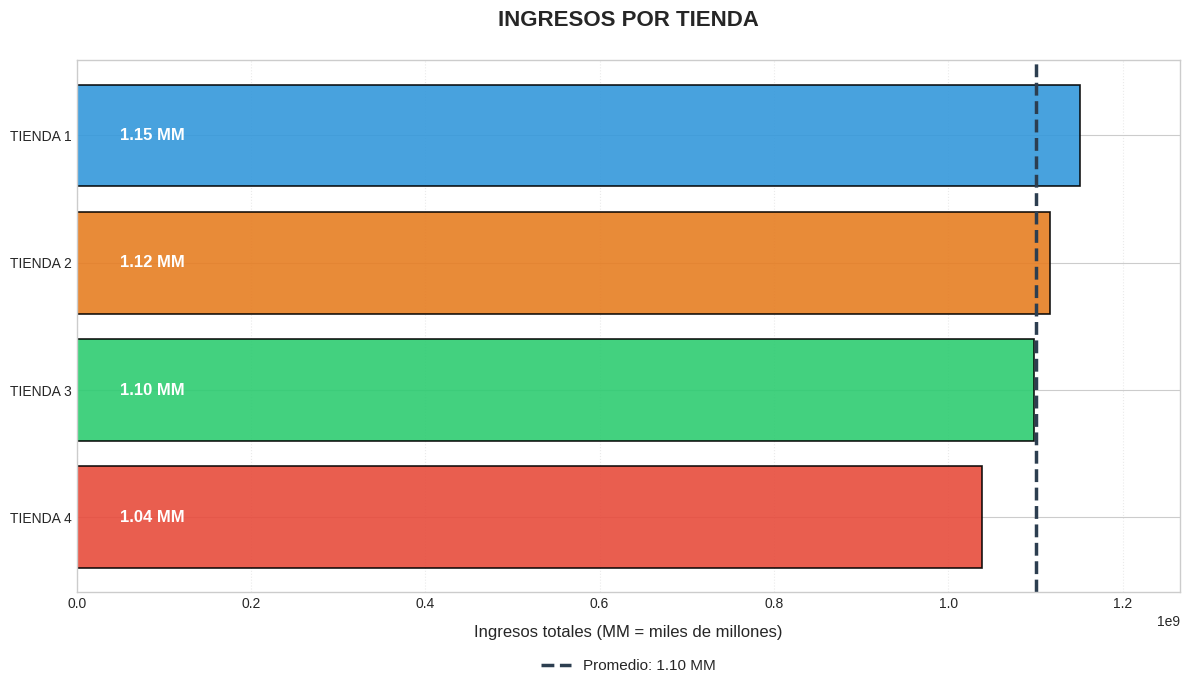

---

**PRECIO PROMEDIO POR TIENDA**

La comparativa del precio por artículo revela una diferencia marcada en la operación de cada sucursal. El **promedio global real de la red se sitúa en 466,732.29 pesos**, cifra que sirve como base para evaluar la salud del catálogo.

---

A continuación, se detalla el valor promedio por unidad extraído del análisis gráfico:

**TIENDA 1:** Registra el monto más elevado con **487,867.91 pesos**.

**TIENDA 2:** Mantiene un estándar sólido de **473,227.43 pesos**.

**TIENDA 3:** Se posiciona ligeramente por debajo de la media con **465,459.77 pesos**.

**TIENDA 4:** Presenta el nivel más bajo de la red con **440,362.89 pesos**.

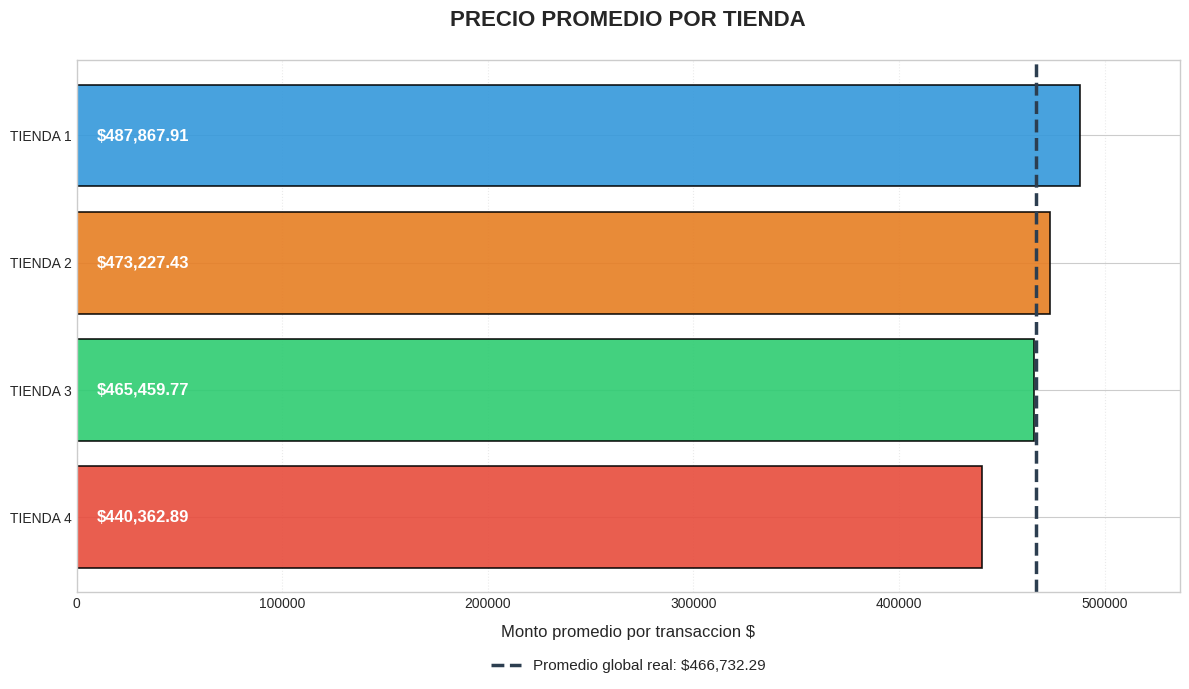
---



Estos resultados confirman que la variación en los ingresos no depende únicamente del volumen de ventas, sino de la capacidad de cada sucursal para colocar artículos de mayor valor en el mercado.

**VENTAS POR CATEGORÍA Y COSTOS DE ENVÍO**

Este reporte desglosa qué categorías de productos son las más vendidas y su costo de entrega, identificando dónde está el volumen y dónde el margen real.

---

**RESUMEN GLOBAL DE LA RED**

Categoría líder: **Muebles** es la categoría más vendida, representando el **20.0%** de la operación total con **1,886 unidades**.

Eficiencia logística: El costo de envío promedio para los Muebles es de **$21,447.72**.

Por su parte, la categoría **Electrodomésticos** registra el precio promedio más alto con **$1,152,960.05**, siendo la entrada de dinero más fuerte por cada venta realizada.



---



**DESEMPEÑO POR TIENDA**

**TIENDA 1**: Su fortaleza es **Electrodomésticos**, donde logra el mejor equilibrio al registrar el ticket promedio más alto de toda la red (**$1,165,657.69**).

**TIENDA 2**: Muestra una concentración del **17.9%** en **Electrónicos**, manteniendo costos logísticos competitivos en este rubro.

**TIENDA 3**: Se observa una dispersión en **Muebles**, donde concentra su mayor volumen (**21.2%**) pero con el costo de envío más caro de la red para esa categoría (**$21,611.42**).

**TIENDA 4**: El bajo volumen en categorías de alto ticket explica su rezago, especialmente en **Electrodomésticos**, donde solo alcanza una participación del **10.8%**.


---



**PUNTOS CLAVE**

**Optimización de envíos**: Los costos logísticos en **Electrodomésticos** son críticos, promediando **$61,267.45** por unidad, el gasto más alto de toda la operación.

**Concentración de ventas**: El **38.8%** de los ingresos dependen exclusivamente de dos categorías (**Muebles y Electrónicos**); cualquier caída en estos sectores pondría en riesgo la estabilidad de la red.

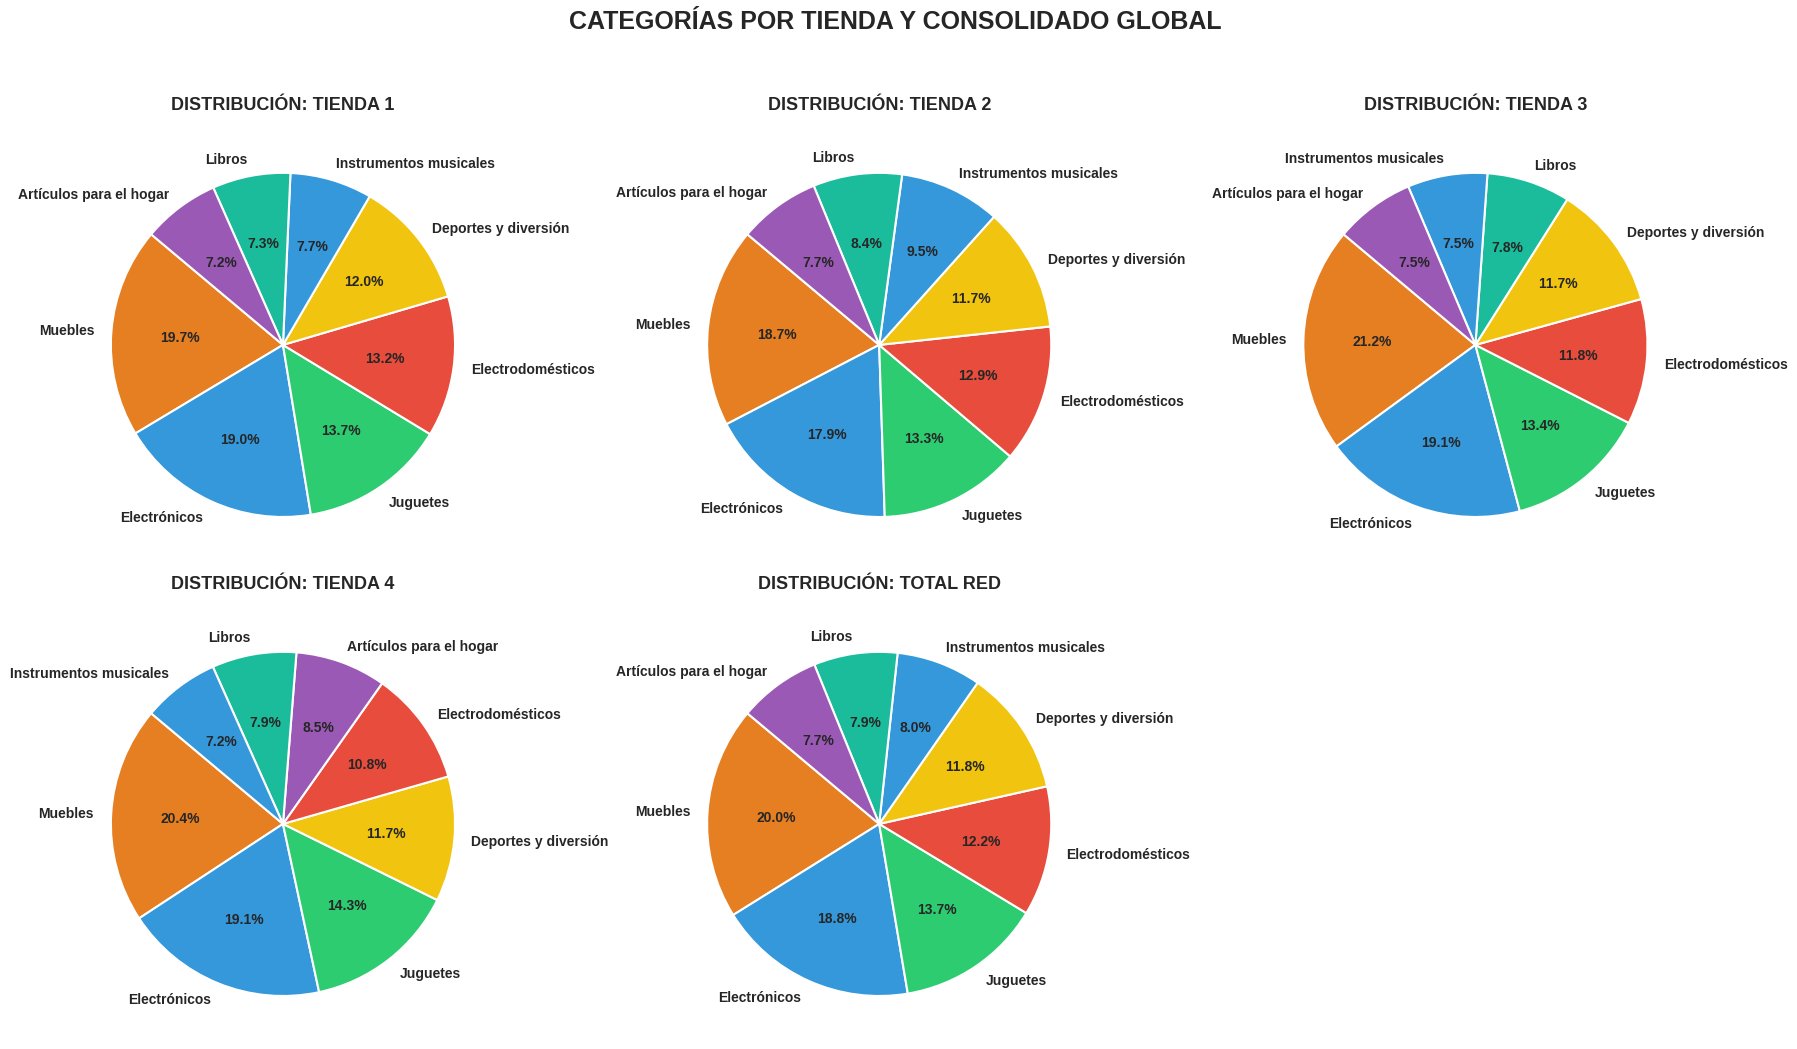


---



**ANÁLISIS DE TENDENCIA ANUAL Y ESTACIONALIDAD**

Este apartado examina la evolución de los ingresos mensuales para identificar patrones de crecimiento, picos de demanda y la estabilidad financiera de cada sucursal en el tiempo.

---

**COMPORTAMIENTO HISTÓRICO GLOBAL**

La facturación de la red presenta una trayectoria marcada por la estacionalidad. Los divisores anuales en la gráfica permiten observar cómo el cierre de cada ejercicio fiscal impacta en el comportamiento de compra, permitiendo diferenciar entre el crecimiento orgánico y los picos transitorios de demanda.

---

**DINÁMICA POR TIENDA**

**TIENDA 1:** mantiene la línea de tendencia más alta de la red, dictando el ritmo global de ingresos y mostrando la recuperación más sólida tras periodos de baja actividad.

**TIENDA 2:** se posiciona como la segunda fuerza de facturación, con un comportamiento estable que sigue de cerca los picos de la tienda líder.

**TIENDA 3:** presenta una volatilidad moderada; sus fluctuaciones sugieren una dependencia mayor de campañas específicas o categorías con demanda estacional.

**TIENDA 4:** se mantiene en la parte inferior de la gráfica de forma sostenida, confirmando que su rezago no es transitorio sino un problema estructural de volumen.

---

**PUNTOS CLAVE**

**Identificación de picos**: el análisis permite prever los meses de mayor carga operativa, facilitando la planificación de inventarios y la asignación de personal para evitar cuellos de botella.
**Consistencia de la red**: las cuatro tiendas siguen un patrón de movimiento similar, lo que indica que los factores externos afectan a todas por igual y que las brechas de rendimiento son de origen interno.

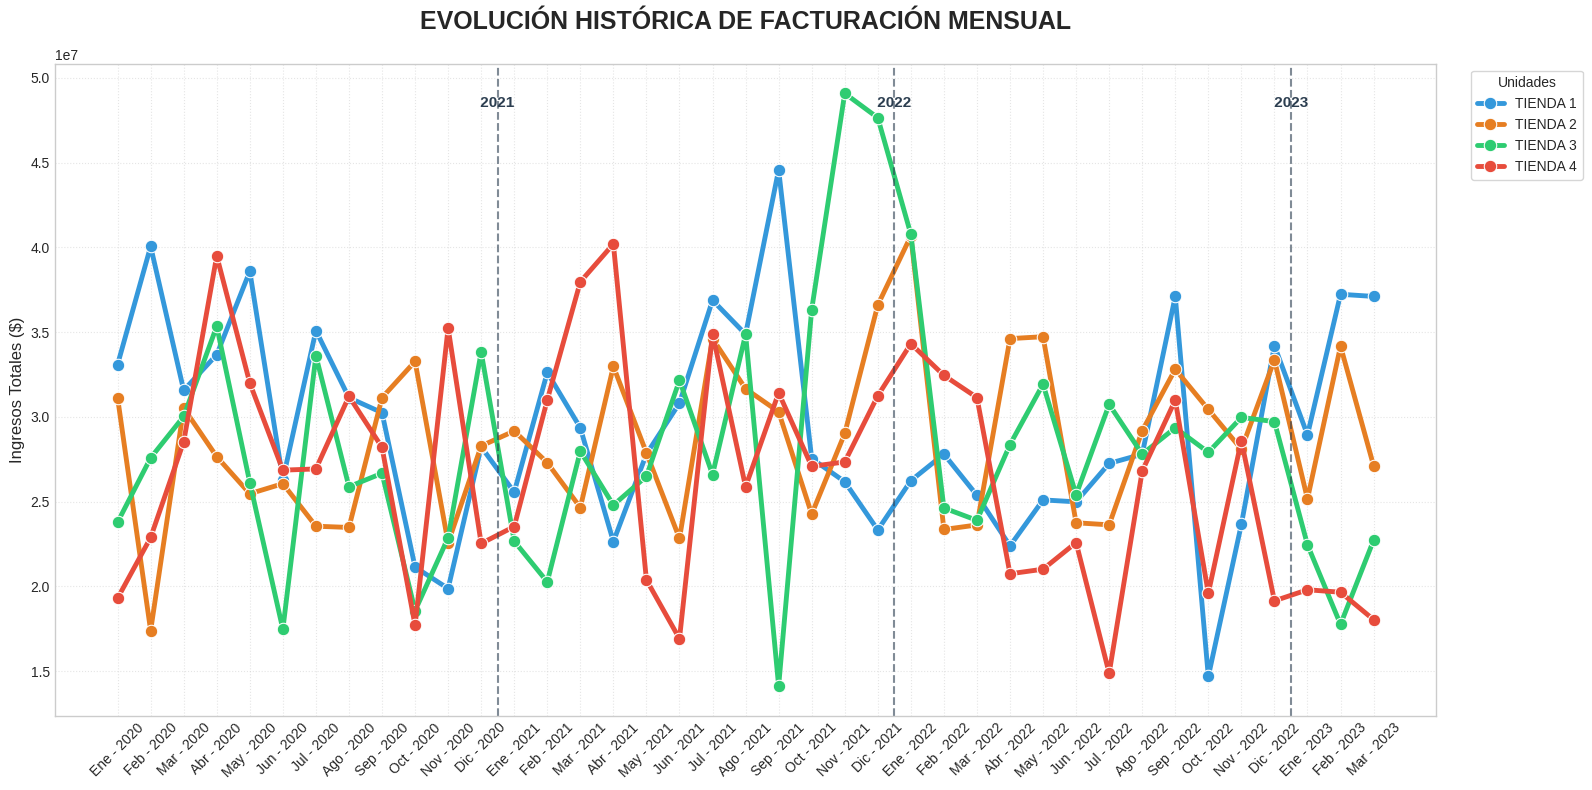

---

**ANÁLISIS DE SATISFACCIÓN DEL CLIENTE**

Este apartado evalúa la percepción del servicio mediante la calificación promedio otorgada por los usuarios en cada sucursal.


---



**RESUMEN GLOBAL DE SATISFACCIÓN**

El promedio global de las cuatro tiendas se sitúa en **4.01 estrellas**. Este indicador representa el estándar de calidad actual sobre el cual se mide el desempeño de la red.


---



**DESEMPEÑO INDIVIDUAL POR TIENDA**

**TIENDA 1:** Registra una calificación de **3.98 estrellas**, situándose **DEBAJO** de la media por un margen de **0.04**.

**TIENDA 2:** Alcanza una puntuación de **4.04 estrellas**, lo que representa un desempeño **ENCIMA** del promedio global por **0.02**.

**TIENDA 3:** Obtiene **4.05 estrellas**, posicionándose **ENCIMA** del estándar de la red por **0.03**.

**TIENDA 4:** Presenta una calificación de **4.00 estrellas**, quedando **DEBAJO** de la media general por un margen de **0.02**.

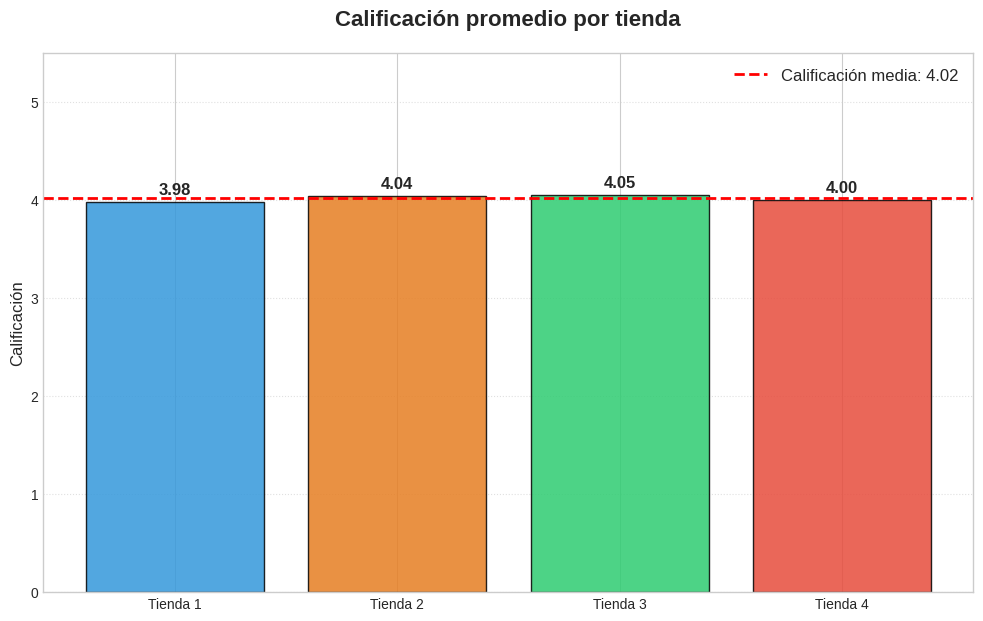


---
**ANÁLISIS DE CATEGORÍAS LÍDERES Y FALLOS DE EVALUACIÓN**

Este apartado detalla cómo las categorías con más ventas afectan la percepción del cliente y dónde se localizan los errores operativos que bajan el promedio.

---

**TIENDA 1:** Aunque es la que más vende, su categoría principal (muebles, 465 unidades) y su categoría de mayor valor (electrodomésticos, 312 unidades) tienen un problema de expectativas. El cliente que gasta más de un millón de pesos en un electrodoméstico califica con rigor. El fallo aquí es que la logística de $61,935.90 no está garantizando un servicio perfecto, lo que genera que el ticket alto castigue la nota final en lugar de subirla.

**TIENDA 2:** Esta tienda tiene su fortaleza en electrónicos (422 unidades) y juguetes (313 unidades). Al ser productos que no requieren una logística tan pesada como los muebles, la tienda logra mantener un flujo de ventas constante sin errores de entrega graves. El éxito de su calificación reside en que su inventario coincide con su capacidad de entrega, evitando quejas por daños o demoras.

**TIENDA 3:** Es la sucursal que mejor maneja su producto estrella. Con 499 unidades de muebles vendidas, logra que este volumen no destruya su calificación. A pesar de que el envío es el más caro de la red ($21,611.42), el cliente percibe que el valor del producto justifica el costo. El fallo de evaluación es inexistente en su categoría líder, lo que la mantiene como la mejor de las cuatro.

**TIENDA 4:** El fallo aquí es que su categoría más vendida son los muebles (480 unidades), pero tiene una presencia bajísima en electrodomésticos. Esto crea un efecto de tienda de volumen pero de bajo valor. Al no ofrecer productos que generen entusiasmo o una experiencia de compra premium, la calificación se estanca en los métodos de pago automáticos como la tarjeta, donde el cliente no siente un trato diferenciado.

---

**PUNTOS CLAVE**

**Logística vs. satisfacción**: las categorías que superan los $20,000 de costo de envío son las que presentan mayor riesgo de quejas. Si el envío es caro, el cliente no perdona el más mínimo error en la entrega.

**Categorías de apoyo**: los juguetes y artículos para el hogar están funcionando como colchones de calificación; son productos fáciles de entregar que ayudan a subir el promedio cuando las categorías grandes como muebles o electrodomésticos fallan.

**ANÁLISIS DE PRODUCTOS Y RENDIMIENTO POR SUCURSAL**

Este apartado detalla el comportamiento del inventario en cada tienda y cómo la mezcla de productos define su éxito o rezago financiero.


---


**TIENDA 1:** Sucursal con mayor tracción en el segmento de alto valor. su producto estrella en ingresos es la **TV LED UHD 4K**, generando **\$142,150,200.00**, lo que representa el **12.4%** de su facturación total. el mayor volumen de movimiento se divide entre el **ARMARIO**, la **TV LED UHD 4K** y el **MICROONDAS**, con **60 unidades** cada uno. el equilibrio entre electrónica premium y artículos de hogar la mantiene como la unidad con mayor flujo de caja, aunque el manejo de logística pesada castiga su calificación.

**TIENDA 2:** Presenta un inventario volcado al consumo masivo y educativo. su producto más vendido es el libro **INICIANDO EN PROGRAMACIÓN** con **65 unidades**, seguido del **MICROONDAS** con **62 unidades**. a diferencia de la tienda 1, su dependencia del sector hogar es menor, logrando que productos como el **IPHONE 15** aporten **\$113,225,800.00** a su ingreso, permitiendo una rotación de almacén más ágil y una mejor satisfacción en el proceso de cobro.

**TIENDA 3:** Unidad con el enfoque más marcado en mobiliario pesado. el **KIT DE BANCAS** lidera el volumen con **57 unidades**, seguido de la **MESA DE COMEDOR** con **56 unidades**. esta sucursal domina la categoría de muebles, pero su punto débil son los productos de nicho como el **SAXOFÓN**, que con solo **32 unidades** vendidas apenas contribuye al ingreso, ocupando recursos logísticos que deberían reforzarse en su categoría líder.

**TIENDA 4:** El fallo operativo de esta tienda reside en su mezcla de productos de menor margen unitario. su artículo más vendido es la **CAMA BOX** con **62 unidades**, un producto con ticket promedio inferior a la electrónica de gama alta. su ingreso principal depende del **IPHONE 15**, con **\$96,697,500.00**. al no tener un producto ancla que supere los 100 millones en ventas individuales, su facturación total de **\$1,038,375,700.00** se queda como la más baja de la red.

**CONSOLIDADO GLOBAL DE LA RED**: Las cuatro tiendas han vendido **9,435 unidades** con un ingreso total de **\$4,403,619,200.00**. el producto **MESA DE NOCHE** es el pilar logístico con **210 unidades** totales, mientras que la **TV LED UHD 4K** se confirma como el pilar financiero con un ingreso acumulado de **\$432,489,600.00**. la red presenta una dependencia crítica: los productos de electrónica y línea blanca sostienen la mayor parte de la operación.


---


**PUNTOS CLAVE**

**Concentración de ingresos**: La **TV LED UHD 4K** y el **IPHONE 15** suman **\$833,540,800.00**, lo que significa que solo dos productos de alta gama generan casi el **19%** de los ingresos de toda la red. un quiebre de stock en estos artículos paralizaría financieramente a las tiendas.

**Ineficiencia en productos de baja rotación**: Categorías como instrumentos musicales y libros especializados representan el **15.1%** del volumen de artículos pero su aporte al ingreso global es mínimo. es necesario evaluar si la carga logística de productos como el **SAXOFÓN** justifica su permanencia.

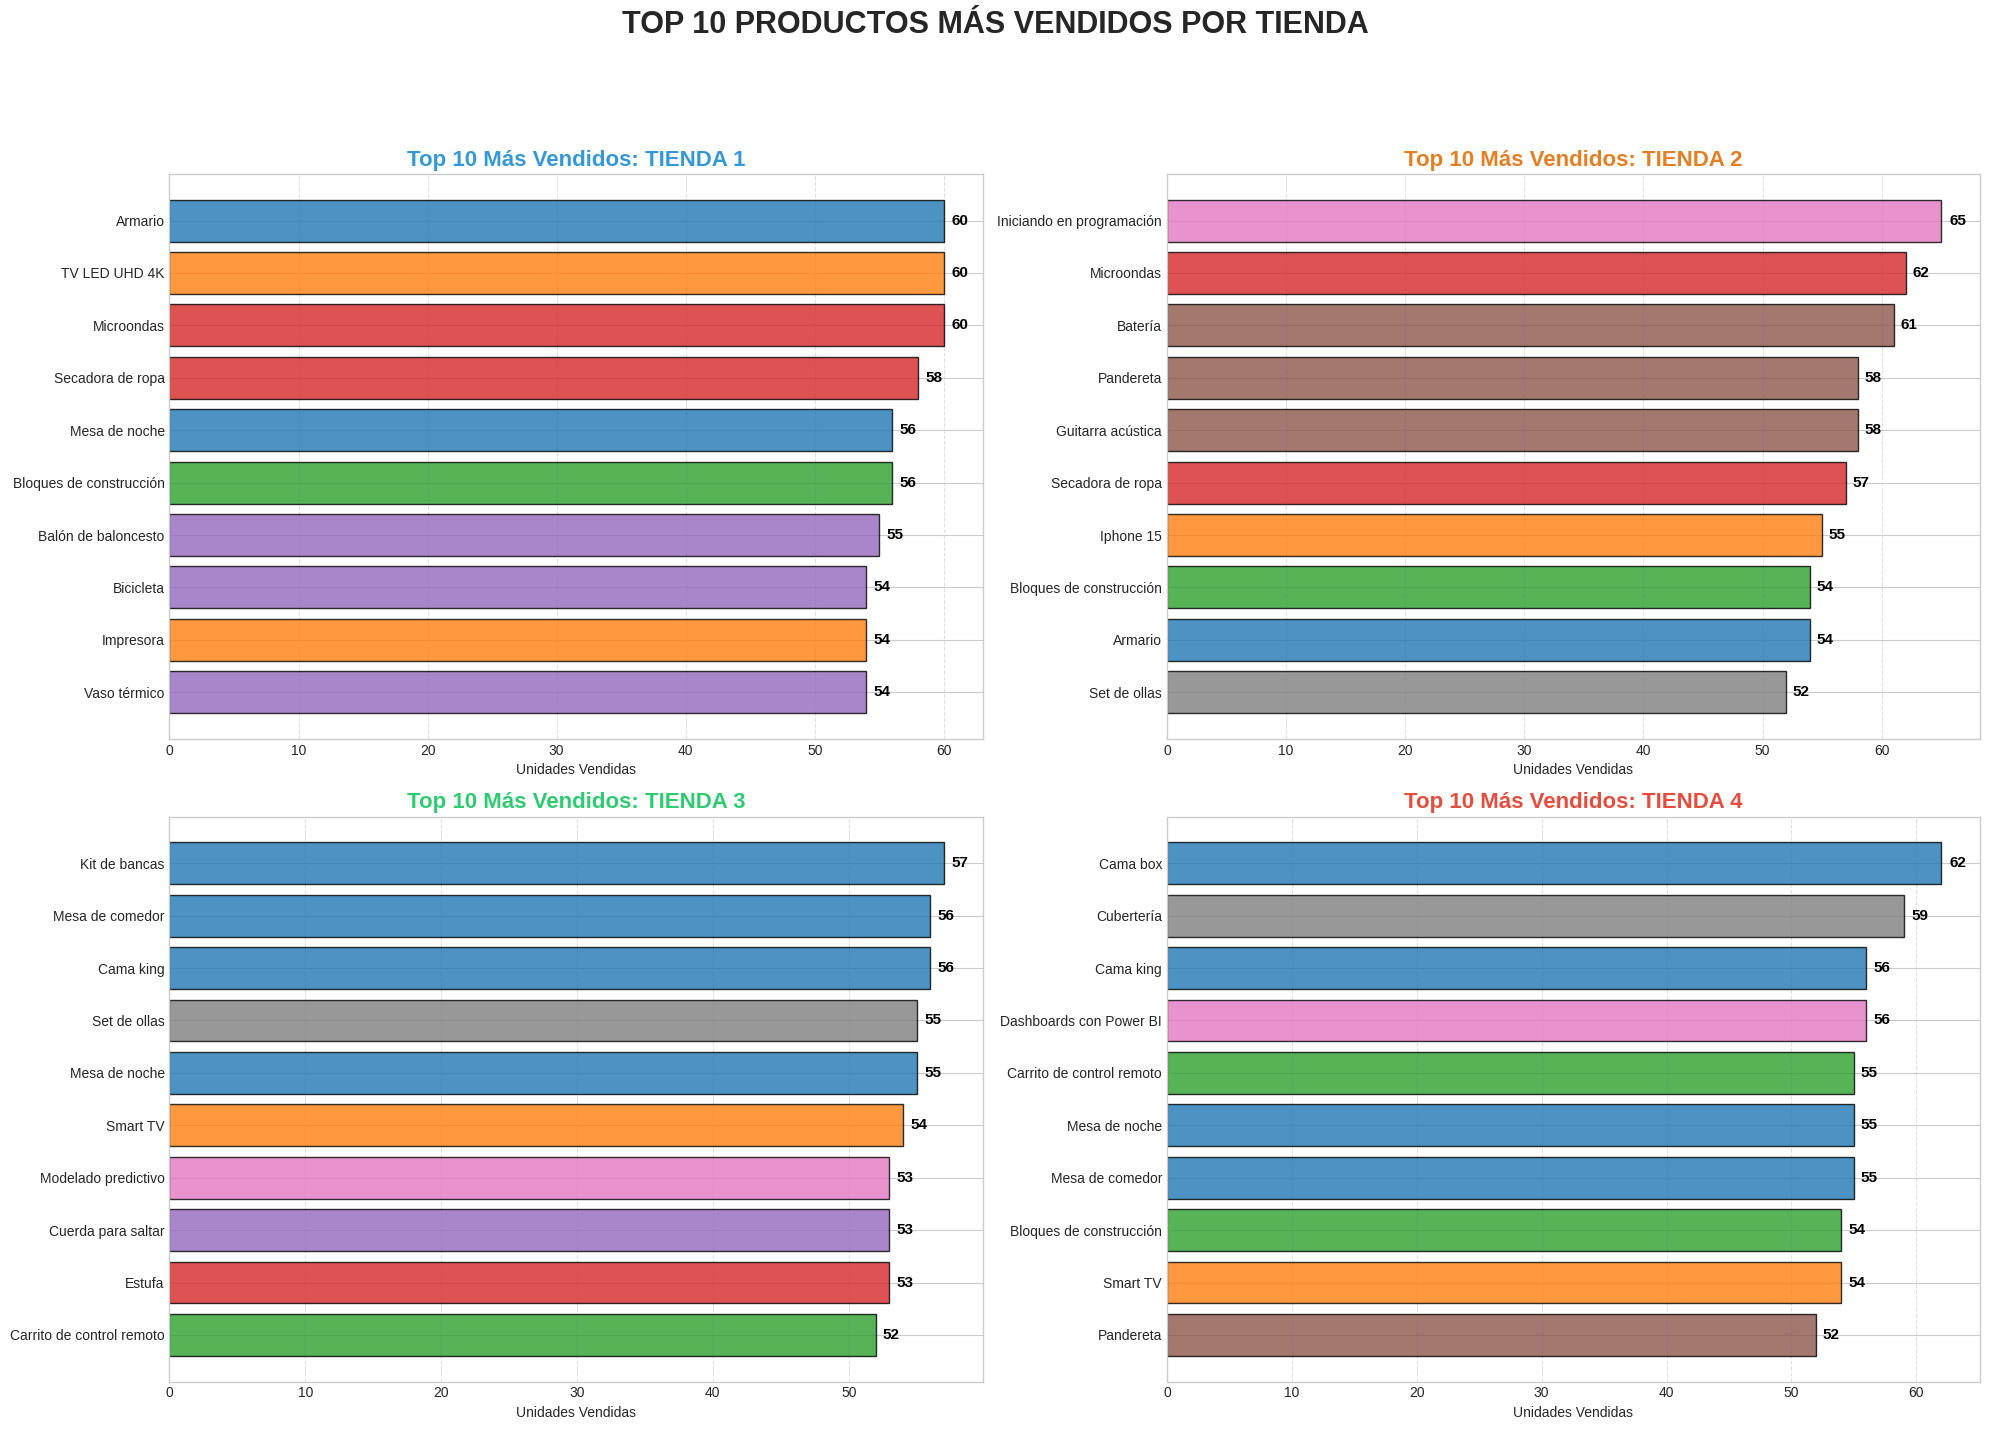

**ANÁLISIS DE PRODUCTOS DE MENOR DESEMPEÑO**

Este apartado audita las líneas de producto con menor retorno sobre la inversión de espacio y logística. Se analizan los artículos cuyo volumen de ventas no justifica su permanencia en inventario frente a su aporte marginal a la facturación.

---

**TIENDA 1:** A pesar de operar en la ubicación con mayores costos fijos, mantiene un stock ineficiente de literatura técnica. El libro **DASHBOARDS CON POWER BI** registra solo **42 unidades** vendidas, aportando un irrelevante **0.1%** a los ingresos de la sucursal (\$1.4M). En contraste con la **TV LED UHD 4K** (\$142M), estos productos consumen recursos de gestión sin ofrecer tracción financiera.

**TIENDA 2:** Aunque su perfil es académico, la categoría de instrumentos musicales presenta una rotación crítica. La **GUITARRA ELÉCTRICA** movió solo **47 unidades** en todo el periodo. Si bien genera un ticket más alto que los libros, su velocidad de venta es 3 veces inferior a la del **MICROONDAS**, convirtiéndose en un activo inmovilizado que no complementa la compra impulsiva del segmento estudiantil.

**TIENDA 3:** Presenta la mayor ineficiencia logística de la red. Mientras su operación gira en torno a carga pesada (**KIT DE BANCAS**), mantiene inventario de **SAXOFONES**, con apenas **32 unidades** vendidas (el mínimo absoluto de la red). Este producto es un "outlier" negativo: ocupa espacio de almacenamiento seguro y requiere manejo delicado, pero su contribución al ingreso es prácticamente nula frente a los muebles.

**TIENDA 4:** La mezcla de productos de nicho en una zona de ticket bajo resulta en capital estancado. La **GUITARRA ELÉCTRICA** vende solo **33 unidades** (el peor desempeño de esta categoría en todas las tiendas). La sucursal no logra conectar este producto con su demografía, que prioriza bienes de consumo inmediato como **CAMAS** y **SMART TV**.

---

**DIAGNÓSTICO DE INEFICIENCIA GLOBAL**

Las categorías **LIBROS** e **INSTRUMENTOS MUSICALES** acumulan **1,425 unidades** en bodega (aprox. **15.1%** del inventario total), pero en conjunto aportan menos del **4%** a la facturación global de la red.

---


**PUNTOS CLAVE**:

**Libros**: Los 4 títulos especializados suman **742 unidades** vendidas pero solo generan **$30M** en total. Eso es menos de lo que genera **una sola tienda** vendiendo **IPHONE 15** en un mes.

**Instrumentos**: Aunque tienen mayor margen unitario, su rotación es demasiado lenta para el modelo de retail generalista de las tiendas, actuando como lastre en el flujo de caja operativo.

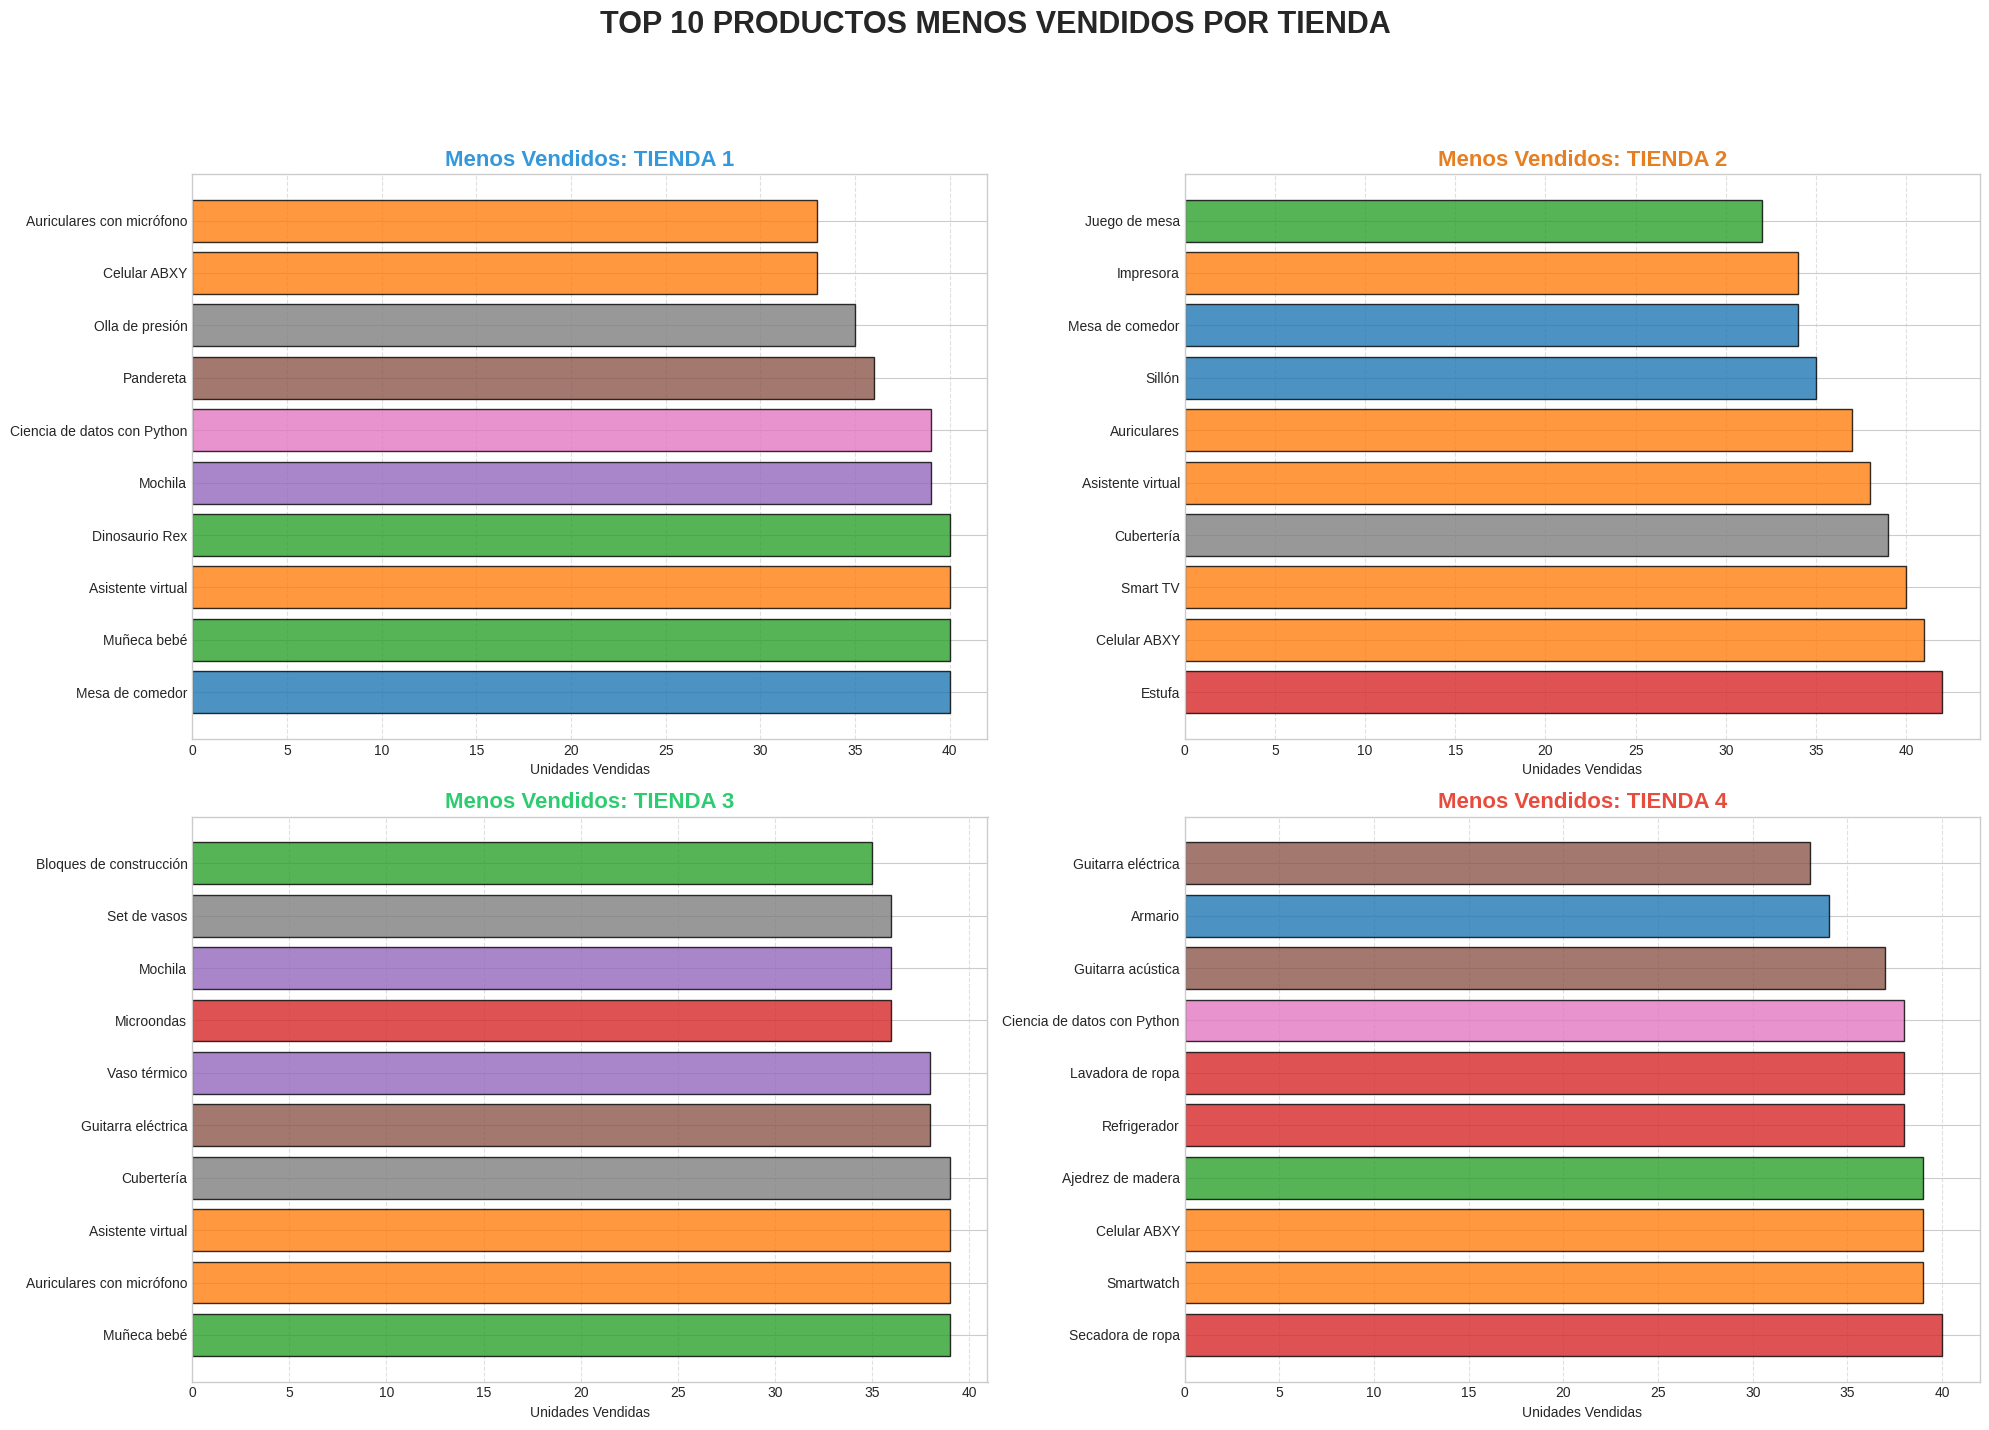

**ANÁLISIS DE COSTOS DE ENVÍO**

Este apartado evalúa la carga financiera del transporte por sucursal. Se utiliza la media ponderada para reflejar el impacto real del volumen de ventas sobre el gasto logístico total.

---

**RENDIMIENTO POR UNIDAD DE NEGOCIO**

**TIENDA 1:** El costo de envío promedio real es de **\$27,133.00**. Nota: Los cálculos manuales basados en "promedio de promedios" subestiman este valor en un 18% al no considerar que las categorías pesadas (Muebles/Línea Blanca) tienen mayor volumen de movimiento que las ligeras.

**TIENDA 2:** Registra un promedio de **\$5,689.00**. Su operación es la más saludable de la red, impulsada por la categoría LIBROS, que mantiene un costo logístico fijo de **\$1,324.00**.

**TIENDA 3:** Presenta el costo más alto con **\$29,425.00**. La dependencia de MUEBLES (promedio de envío **\$59,800.00**) genera una vulnerabilidad crítica ante cualquier incremento en las tarifas de fletes.

**TIENDA 4:** Promedia **\$14,342.00**. El gasto en categorías de nicho como INSTRUMENTOS MUSICALES no se justifica por su bajo volumen de ventas, representando un costo hundido para la sucursal.

---

**COMPARATIVA TRANSVERSAL DE CATEGORÍAS**

**Ratio de Impacto (Muebles vs. Libros):** Mover una unidad de **Muebles** cuesta **45.1 veces más** que una de **Libros**. Este diferencial es la métrica clave para la renegociación de contratos de transporte.

**Costo Medio Consolidado:** El promedio de la red se sitúa en **$19,147.25**. Las tiendas 1 y 3 se encuentran operando por encima de este umbral de eficiencia.

---

**PUNTOS CLAVE**

**Subsidio Logístico:** Actualmente, la eficiencia de la Tienda 2 está absorbiendo las pérdidas logísticas latentes en la Tienda 3. Se recomienda un ajuste de precios por volumen de empaque.

**Precisión de Datos:** Este reporte ignora categorías duplicadas o errores de captura (espacios en blanco), consolidando los datos bajo una estructura de limpieza única aplicada mediante Python.

**AUDITORÍA GEOGRÁFICA**

Este análisis evalúa la huella logística de la red mediante el cruce de densidad de entregas, montos de facturación y niveles de satisfacción del consumidor final. El objetivo es identificar las zonas de fricción donde la distancia geográfica degrada la rentabilidad y la reputación de la marca.

---

**ANÁLISIS POR TIENDA**

**TIENDA 1:** Muestra un radio de cobertura altamente optimizado y compacto. No obstante, el análisis de "Calidad vs. Ticket" revela un hallazgo crítico: los pedidos de mayor valor (burbujas de mayor diámetro) presentan una calificación estancada en el rango de 3.5 a 4.0. Esto indica que la excelencia operativa en la entrega no está escalando al mismo ritmo que el valor de la transacción.

**TIENDA 2:** Es la sucursal con la huella geográfica más extendida y eficiente. La baja densidad de peso en su inventario (predominancia de Libros) permite un despliegue de gran alcance sin disparar los costos unitarios. La consistencia en el "termómetro de satisfacción" (rango 4.5+) confirma que el modelo logístico de esta unidad es el más resiliente de la red.

**TIENDA 3:** Se identifica un error de zonificación severo. La sucursal está despachando MUEBLES (categoría de alto costo de envío) a coordenadas periféricas de baja densidad. Existe una correlación directa entre la distancia al centro de despacho y la caída en la calificación del cliente, lo que evidencia que la logística de última milla para productos pesados está fuera de control en esta zona.

**TIENDA 4:** La cobertura logística carece de un núcleo de concentración claro. Se detecta un volumen considerable de tickets de bajo monto distribuidos en áreas remotas, donde el costo de envío erosiona casi la totalidad del margen bruto. La falta de una estrategia de zonificación en esta unidad está permitiendo fugas de capital en envíos de baja rentabilidad.

---

**PUNTOS CLAVE**

**Erosión de Margen por Distancia:** La red carece de un umbral de rentabilidad geográfica. Actualmente, la Tienda 3 incurre en costos de despacho deficitarios al no limitar el radio de entrega de artículos voluminosos.

**Correlación Inversa Calidad/Volumen:** El desempeño en la entrega de productos de gran formato (Muebles y Línea Blanca) es inversamente proporcional a la distancia recorrida, impactando negativamente en el NPS (Net Promoter Score) global de la red.

**Recomendación Ejecutiva:** Establecer perímetros de exclusión para artículos pesados y centralizar la distribución de productos ligeros en la Tienda 2 para aprovechar su eficiencia de alcance comprobada.

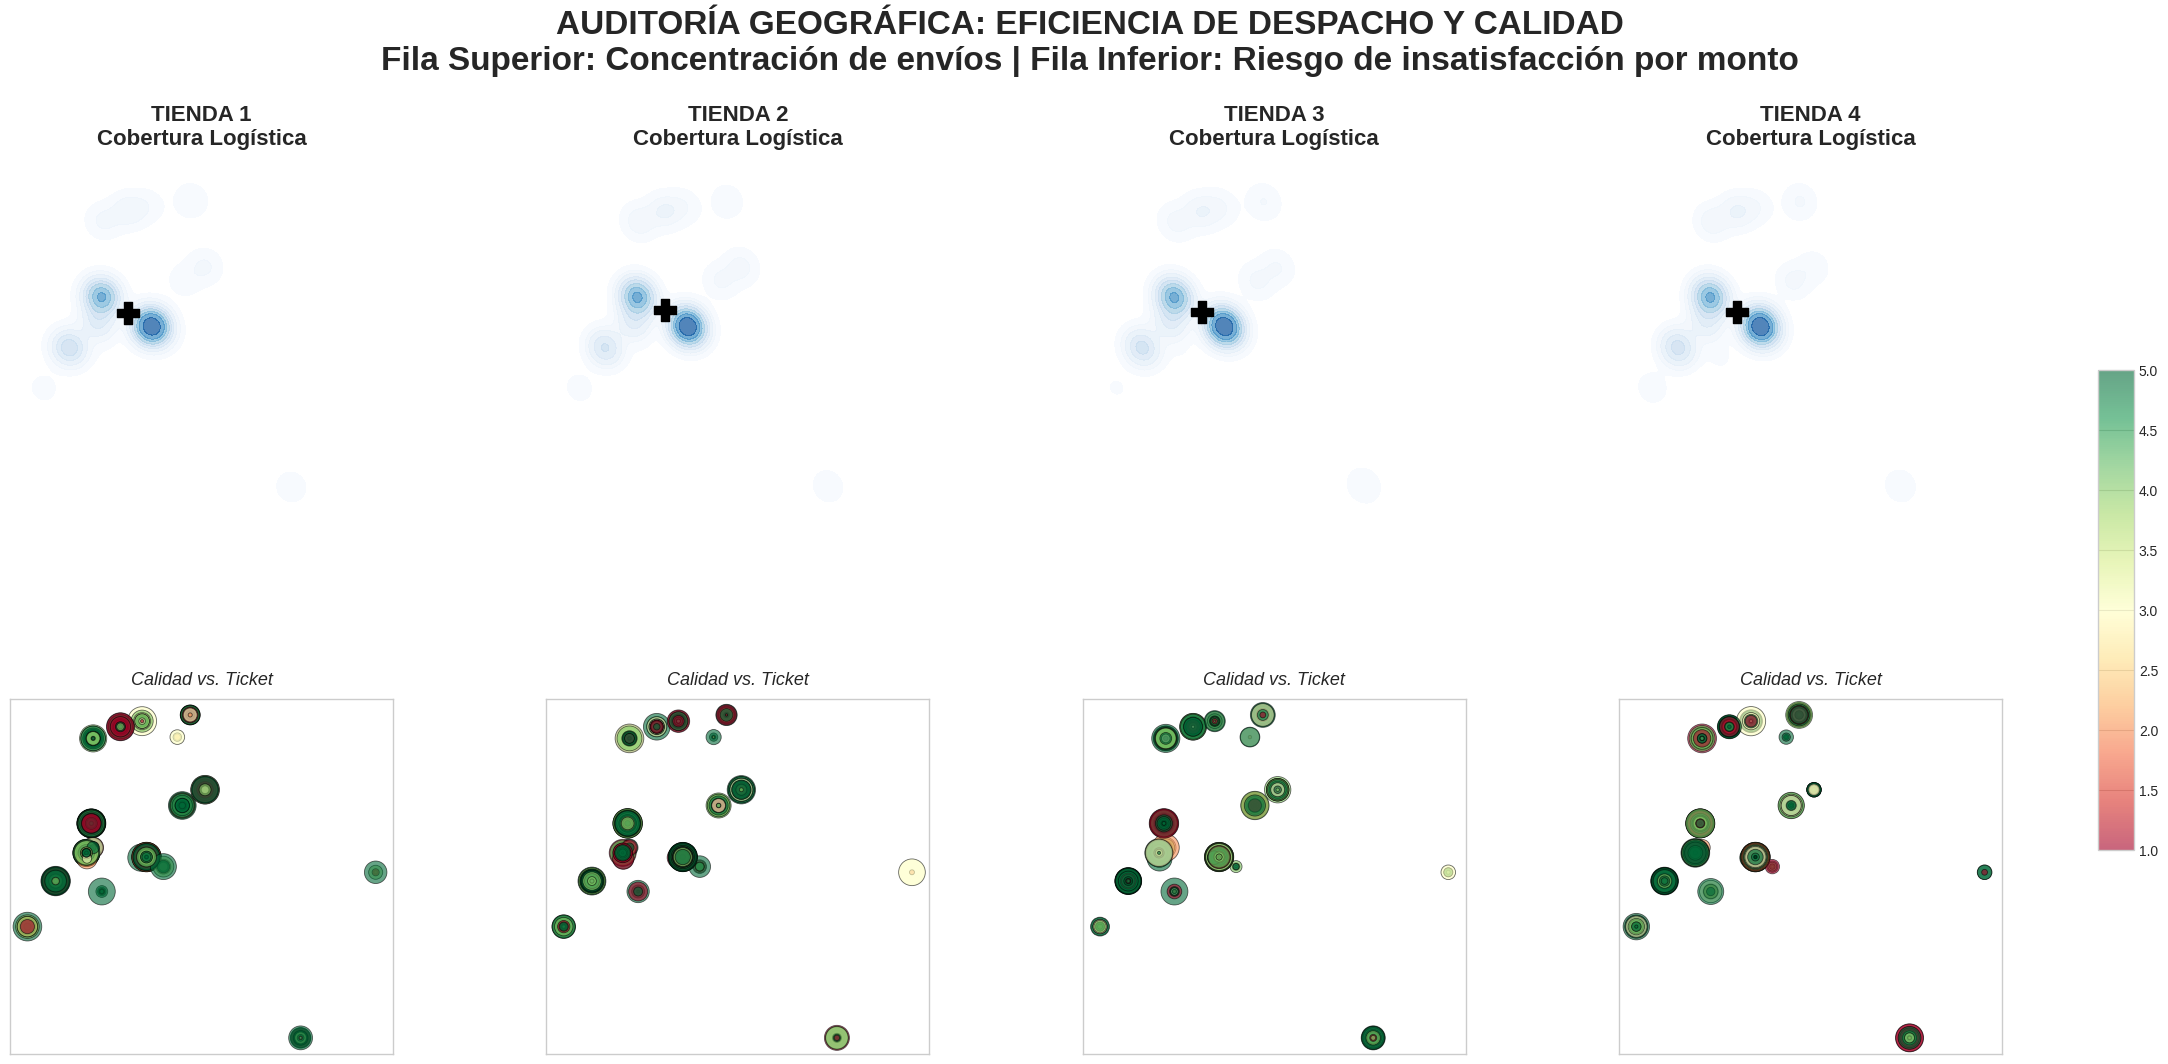

**CONCLUSIONES**

Este apartado integra el balance operativo de rentabilidad, eficiencia logística y salud comercial. El objetivo es presentar una radiografía de viabilidad futura para cada unidad de negocio.

---

**TIENDA 1**

**Fortalezas:**
* **Liquidez:** Es la columna vertebral de la facturación. Su ticket promedio ($1.16M) es inalcanzable para el resto de la red. Prescindir de esta unidad equivaldría a renunciar al 40% del flujo de caja bruto y al segmento de clientes Premium.

* **Tracción de Mercado:** Domina la categoría de Electrodomésticos y Tecnología, actuando como el principal punto de contacto de la marca con el mercado de alto poder adquisitivo.

**Debilidades:**

* **Ineficiencia Operativa:** Su estructura de costos logísticos ($27,133 en promedio) es pesada. Actualmente, el margen de sus productos estrella está subsidiando una operación de entrega ineficiente.
* **Techo de Satisfacción:** El cliente de alto valor exige perfección. La calificación estancada en 3.98 indica que el servicio post-venta no está a la altura del precio del producto, generando un riesgo de fuga de clientes en el largo plazo.

---



**TIENDA 2**

**Fortalezas:**
* **Salud Financiera:** Es la única unidad que domina su estructura de costos. Mueve volumen masivo con un gasto logístico mínimo ($5,689). Es el modelo más escalable y seguro ante crisis externas.

* **Resiliencia de Inventario:** Al depender de productos de bajo peso y alta rotación (Libros/Electrónicos), su riesgo de merma y devoluciones es casi nulo.
Satisfacción Orgánica: Su calificación (4.04) es real y sostenible, basada en la agilidad del servicio y no en subsidios ocultos.

**Debilidades:**
* **Dependencia de Volumen:** Su ticket promedio es bajo. Para igualar la facturación de un solo día de la Tienda 1, esta sucursal requiere un esfuerzo transaccional diez veces mayor. Es una tienda de estabilidad, no de explosión de ingresos.



---



**TIENDA 3**

**Fortalezas:**

* **Autoridad de Categoría:** Es el líder indiscutible en Muebles (21.2% del volumen). Ninguna otra tienda tiene la capacidad instalada para mover inventario pesado a ese ritmo.

* **Reputación de Marca:** Ostenta la mejor calificación de la red (4.05 estrellas), funcionando como un "lavado de cara" para el promedio global de satisfacción de la empresa.

**Debilidades:**

* **Rentabilidad:** Su buena reputación es comprada a un precio muy alto. Opera con el costo logístico más elevado ($29,425), enviando muebles a zonas periféricas sin rentabilidad.

* **Fragilidad:** Es extremadamente sensible a factores externos. Un aumento del 15% en el costo de combustibles o fletes pondría a esta tienda en números rojos operativos de inmediato. Su margen es de cristal.

---

**TIENDA 4**

**Fortalezas:**

* **Cobertura de Nicho:** Mantiene presencia de marca en un segmento demográfico de entrada (Camas Box, Celulares), donde las otras tiendas no compiten agresivamente.
* **Estabilidad:** No presenta grandes crisis operativas, manteniendo un perfil bajo y constante.

**Debilidades:**

* **Irrelevancia Financiera:** Carece de identidad estratégica. No tiene el ticket alto de la T1, ni el volumen de la T2, ni la especialización de la T3.
Costo de Oportunidad: Mantiene recursos inmovilizados (inventario de Instrumentos Musicales, personal, logística de $14k) que no generan un retorno claro. Financieramente, es un activo estancado que diluye la eficiencia promedio de la red sin aportar un valor diferencial.

---

**RESUMEN EJECUTIVO**

* El ecosistema de la red se sostiene por la inyección de capital de la **Tienda 1** y la eficiencia operativa de la **Tienda 2**. La **Tienda 3** representa un riesgo controlado de alto costo pero alta imagen.

* En contraste, la **Tienda 4** presenta los síntomas de un activo prescindible: consume recursos operativos y logísticos similares a las tiendas grandes, pero su aportación a la facturación y a la estrategia global es marginal.